# Biased Blocks

Flexible biased-block notebook. Build views by genotype, line, cohort, dataset, animal, or custom combinations, prepare the block-labeled RT tables once, then choose a plot layout without recomputing.

## 1. Setup

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "analysis" / "daily_merge.py").exists() and (candidate / "DataFiles").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find the Mafalda_analysis repo root from the current working directory."
    )

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

ROOT

PosixPath('/Users/mafaldavalente/Documents/Mafalda_analysis')

## 2. Choose Datasets

`DATASET_SELECTIONS` is the safest option when mixing lines/cohorts. Use `ANIMAL_SELECTION` for a one-animal review.

In [2]:
LINES = ["CNTNAP2"]
COHORTS = ["cohort4"]

# Explicit selections can mix lines/cohorts, e.g.:
# DATASET_SELECTIONS = [("CNTNAP2", "cohort2"), ("CNTNAP2", "cohort3"), ("SHANK3", "cohort1")]
DATASET_SELECTIONS = [("CNTNAP2", "cohort4")]

# Optional: restrict to one animal, e.g. "ASD0041". Use None for all animals.
ANIMAL_SELECTION = None

## 3. Choose Comparison

Common presets:

- Compare genotypes within selected datasets: `COMPARISON = "genotypes"`, `SPLIT_BY = "none"`
- Keep cohorts/datasets separate within genotype: `COMPARISON = "genotypes"`, `SPLIT_BY = "dataset"`
- Compare the same genotype across datasets: `COMPARISON = "datasets"`, `GENOTYPES = ["hom"]`
- Compare experimentors within selected datasets: `COMPARISON = "experimentor"`
- One view per animal: `COMPARISON = "animals"`
- Fully custom: `COMPARISON = "custom"` and edit `CUSTOM_SPECS`.

In [3]:
COMPARISON = "genotypes"  # "genotypes", "datasets", "lines", "cohorts", "experimentor", "animals", or "custom"
SPLIT_BY = "none"         # for COMPARISON="genotypes": "none", "dataset", "line", or "cohort"
GENOTYPES = ["wt", "het", "hom"]

CUSTOM_SPECS = [
    # {"name": "SHANK3 hom", "line": "SHANK3", "genotype": "hom"},
    # {"name": "ASD0041", "animal": "ASD0041"},
]

## 4. Load Data And Build Views

Rerun this if you change dataset selection, comparison mode, genotype selection, animal selection, or custom specs.

In [4]:
from GroupComparison.config import ViewSpec
from Pipeline.group_comparison import (
    build_group_views,
    build_view_style_maps,
    load_groupcomparison_data,
    make_selector,
    summarize_views,
)


data = load_groupcomparison_data(
    lines=LINES,
    cohorts=COHORTS,
    dataset_selections=DATASET_SELECTIONS,
)
df_plot = data["df_plot"].copy()

if ANIMAL_SELECTION is not None:
    df_plot = df_plot[df_plot["animal"].astype(str).str.strip() == str(ANIMAL_SELECTION)].copy()

if COMPARISON == "animals":
    views = [
        ViewSpec(str(animal), lambda d, _animal=str(animal): d[d["animal"].astype(str).str.strip() == _animal].copy())
        for animal in sorted(df_plot["animal"].dropna().astype(str).unique())
    ]
elif COMPARISON == "custom" and CUSTOM_SPECS:
    views = []
    for spec in CUSTOM_SPECS:
        if "animal" in spec:
            views.append(ViewSpec(spec["name"], lambda d, _animal=str(spec["animal"]): d[d["animal"].astype(str).str.strip() == _animal].copy()))
        else:
            views.append(
                ViewSpec(
                    spec["name"],
                    make_selector(
                        genotypes=spec.get("genotypes", spec.get("genotype")),
                        lines=spec.get("lines", spec.get("line")),
                        cohorts=spec.get("cohorts", spec.get("cohort")),
                        dataset_keys=spec.get("dataset_keys", spec.get("dataset_key")),
                    ),
                )
            )
else:
    views = build_group_views(
        df_plot,
        comparison=COMPARISON,
        split_by=SPLIT_BY,
        genotypes=GENOTYPES,
        custom_specs=CUSTOM_SPECS,
    )

print("Loaded datasets:", data["selections"])
print("Usable dataset keys:", data["usable_dataset_names"])
display(summarize_views(df_plot, views))

view_colors, view_styles = build_view_style_maps(df_plot, views)
print("View colors:", view_colors)
print("View styles:", view_styles)

Loaded datasets: [('CNTNAP2', 'cohort4')]
Usable dataset keys: ['CNTNAP2:cohort4']


,view,rows,animals,lines,cohorts,genotypes,experimentor
0,wt,109653,4,CNTNAP2,cohort4,wt,"HY, MV"
1,het,248358,10,CNTNAP2,cohort4,het,"HY, MV"
2,hom,168528,6,CNTNAP2,cohort4,hom,"HY, MV"


View colors: {'wt': '#4D4D4D', 'het': '#7A8F28', 'hom': '#C24A7A'}
View styles: {'wt': {'linestyle': '-', 'marker': 'o', 'markerfacecolor': None}, 'het': {'linestyle': '-', 'marker': 'o', 'markerfacecolor': None}, 'hom': {'linestyle': '-', 'marker': 'o', 'markerfacecolor': None}}


## 5. Prepare Once

This is the expensive step. Rerun it if you change filters, block-label settings, views, or datasets. You do not need to rerun it just to change `LAYOUT` below.

In [8]:
import importlib
import Pipeline.biased_blocks as bb
bb = importlib.reload(bb)

BIASED_SESSION_TYPES = (3, 23)
UNBIASED_RT_SESSION_TYPES = (1, 2)
SHORT_DURATION_VALUE = None  # examples: 0, [0, 8, 16, 32, 64, 120], or None for all
RIGHTWARD_ILD_SIGN = 1
MIN_DIRECTION_IMBALANCE = 0.0
KEEP_ONLY_ANIMALS_WITH_BIASED_SESSIONS = True
PSYCHOMETRIC_L2 = 0.5  # 0 disables regularization; larger values penalize extreme slope/bias/lapse fits more strongly

cfg = bb.default_config()
fcfg = bb.default_filter_config()
style = bb.default_style()

bundle = bb.prepare_biased_blocks(
    df=df_plot,
    views=views,
    cfg=cfg,
    fcfg=fcfg,
    style=style,
    biased_session_types=BIASED_SESSION_TYPES,
    unbiased_rt_session_types=UNBIASED_RT_SESSION_TYPES,
    short_duration_value=SHORT_DURATION_VALUE,
    rightward_ild_sign=RIGHTWARD_ILD_SIGN,
    min_direction_imbalance=MIN_DIRECTION_IMBALANCE,
    keep_only_animals_with_biased_sessions=KEEP_ONLY_ANIMALS_WITH_BIASED_SESSIONS,
    psychometric_l2=PSYCHOMETRIC_L2,
)

print("Filtered rows with block labels:", len(bundle["df_blocks"]))
display(bundle["block_summary"])

Filtered rows with block labels: 0


,line,cohort,genotype,animal,session_type,block_condition,trials


## 5b. Block Label Check

Run this cell to inspect how session types `3` and `23` are being labeled. It shows one table per animal with the session, recorded block number, contiguous block run, and block code: unbiased = `0`, rightward = `1`, leftward = `-1`.

In [ ]:
import pandas as pd
from IPython.display import display

BLOCK_CHECK_SESSION_TYPES = (3, 23)
BLOCK_CODE = {"unbiased": 0, "rightward": 1, "leftward": -1}

df_block_check = bundle["df_filtered"].copy()
session_type = pd.to_numeric(df_block_check["session_type"], errors="coerce")
df_block_check = df_block_check[session_type.isin(BLOCK_CHECK_SESSION_TYPES)].copy()

rows = []
key_cols = [c for c in ["dataset_key", "animal", "session"] if c in df_block_check.columns]

for session_key, session_df in df_block_check.groupby(key_cols, sort=False, dropna=False):
    if not isinstance(session_key, tuple):
        session_key = (session_key,)
    session_info = dict(zip(key_cols, session_key))
    session_type_value = pd.to_numeric(session_df["session_type"], errors="coerce").dropna()
    session_type_value = int(session_type_value.iloc[0]) if not session_type_value.empty else pd.NA

    for run_idx, (block_idx, condition) in enumerate(
        bb.assign_session_block_conditions(
            session_df,
            rightward_ild_sign=RIGHTWARD_ILD_SIGN,
            min_imbalance=MIN_DIRECTION_IMBALANCE,
        ),
        start=1,
    ):
        block_df = session_df.loc[block_idx].copy()
        if pd.isna(condition):
            code = pd.NA
            label = "ambiguous"
        else:
            code = BLOCK_CODE[str(condition)]
            label = str(condition)

        block_number = bb._session_block_number(block_df)
        valid_mask = bb._block_valid_mask(block_df)

        if "trial" in block_df.columns:
            trial_numeric = pd.to_numeric(block_df["trial"], errors="coerce")
            trial_start = int(trial_numeric.min()) if trial_numeric.notna().any() else pd.NA
            trial_end = int(trial_numeric.max()) if trial_numeric.notna().any() else pd.NA
        else:
            trial_start = pd.NA
            trial_end = pd.NA

        rows.append({
            **session_info,
            "session_type": session_type_value,
            "block_run": run_idx,
            "block": block_number,
            "block_code": code,
            "block_label": label,
            "n_trials": int(len(block_df)),
            "n_valid_trials": int(valid_mask.sum()),
            "trial_start": trial_start,
            "trial_end": trial_end,
        })

block_check = pd.DataFrame(rows)
if block_check.empty:
    print("No session type 3 or 23 rows after the current filters.")
else:
    sort_cols = [c for c in ["animal", "session", "block_run"] if c in block_check.columns]
    block_check = block_check.sort_values(sort_cols).reset_index(drop=True)
    for animal, animal_df in block_check.groupby("animal", sort=False, dropna=False):
        print(f"\n{animal}")
        display(animal_df[[c for c in ["session_type", "session", "block_run", "block", "block_code", "block_label", "n_trials", "n_valid_trials", "trial_start", "trial_end"] if c in animal_df.columns]])

block_check


## 6. Plot From Prepared Data

Change `LAYOUT` and rerun this cell without recomputing preparation.

- `block_conditions`: one figure per block condition; lines are selected genotype/view groups
- `genotype_blocks`: one figure per selected genotype/view; lines are block conditions, plus an extra end figure with one row per genotype/view and traces collapsed across ABL 20/40/60
- `animal_blocks`: one figure per animal; lines are block conditions
- `block_condition_params`: one psychometric-parameter summary per ABL; markers are genotype/view means ± SEM across animals
- `block_condition_summary`: ABL-averaged psychometric bias, proportion correct, and JND; markers are genotype/view means ± SEM across animals for rightward and leftward biased blocks
- `block_bias`: two bias summary figures, one by animal and one by genotype/view
- `left_to_right_transition`: one figure per genotype/view, 3 ABL panels, signed choice-right traces for both left-to-right and right-to-left transitions in separate panels
- `left_to_right_transition_genotypes`: one genotype-comparison figure matching the `biased_transition_baseline` logic. Rows are `leftward to rightward` and `rightward to leftward` transitions, columns are `ABL 20`, `40`, and `60`, and lines are genotypes/views. The plotted value is the change in fraction of rightward choices relative to that animal's unbiased-block baseline; ILD groups are baseline-subtracted first and then averaged within animal
- `biased_transition_aligned`: test layout pooling any biased-to-biased transition, aligned to the new favored side
- `biased_transition_collapsed`: test layout pooling any biased-to-biased transition and collapsing ILDs to hard vs easy
- `biased_transition_baseline`: matched ILD transition plot showing change in fraction of rightward choices relative to the animal's unbiased-block baseline, with separate left-to-right and right-to-left rows
- `biased_transition_accuracy_delta`: one genotype/view comparison figure with one row of ABL panels. For each direction, trials are pooled into positive-ILD and negative-ILD groups, and accuracy(positive ILDs) - accuracy(negative ILDs) is calculated per animal. The directional animal means are then averaged separately, and each trace is `((leftward to rightward mean) - (rightward to leftward mean)) / 2`, from 10 valid trials before to 30 valid trials after each transition. Set `SEPARATE_ABLS = False` to pool all ABLs into one panel.
- `biased_transition_rt`: one genotype/view comparison figure of the directional half-difference in correct-trial RT. For each direction and animal, mean RT at positive ILDs minus mean RT at negative ILDs is calculated first; the plotted trace is then `((leftward to rightward contrast) - (rightward to leftward contrast)) / 2`. Set `SEPARATE_ABLS = False` to pool ABLs into one panel.
- `biased_transition_accuracy_delta_durations`: one figure per genotype/view, with ABL 20, 40, and 60 panels. Lines are duration groups; physical trial position is defined before selecting duration or ABL.
- `biased_transition_fit_parameter_summary`: two combined figures. The first has genotype comparison traces for all durations pooled across the top ABL row and the a/b/c parameter summaries below. The second has one genotype row of duration-group traces per selected view, followed by a fourth a/b/c parameter-summary row.
- `all`: make all figure families

In [14]:
import importlib
import matplotlib.pyplot as plt
from IPython.display import display
import Pipeline.biased_blocks as bb

bb = importlib.reload(bb)

LAYOUT = "biased_transition_accuracy_delta"
PLOT_VIEW = None      # set to a view name, e.g. "hom", or None for all selected views
MAX_ANIMALS = None
TRANSITION_BIN_SIZE = 1  # this layout uses -10 to +30 trials around each transition
SEPARATE_ABLS = True     # True shows separate ABL 20, 40, and 60 panels
DURATION_GROUPS = ((8, 16), (32, 64), (120, 0))
FIT_POST_TRANSITION_EXPONENTIAL = True  # False shows binned data only
FIT_PRE_TRANSITION_BASELINE = True      # Fits pre-transition trials as the constant a - b baseline
PLOT_BLOCK_CONDITIONS = ["rightward", "leftward", "unbiased"]

plot_views = [v for v in views if PLOT_VIEW is None or v.name == PLOT_VIEW]
if not plot_views:
    raise ValueError(f"PLOT_VIEW={PLOT_VIEW!r} did not match any selected view.")

plt.close("all")
with plt.ioff():
    out = bb.plot_biased_blocks(
        bundle=bundle,
        views=plot_views,
        layout=LAYOUT,
        view_colors=view_colors,
        view_styles=view_styles,
        block_conditions=PLOT_BLOCK_CONDITIONS,
        max_animals=MAX_ANIMALS,
        transition_bin_size=TRANSITION_BIN_SIZE,
        separate_abls=SEPARATE_ABLS,
        duration_groups=DURATION_GROUPS,
        fit_post_transition=FIT_POST_TRANSITION_EXPONENTIAL,
        fit_pre_transition_baseline=FIT_PRE_TRANSITION_BASELINE,
        show=False,
    )

def display_figures(obj):
    if isinstance(obj, dict):
        if "figure" in obj:
            display(obj["figure"])
            #plt.close(obj["figure"])
        else:
            for value in obj.values():
                display_figures(value)

display_figures(out["figures"])

transition_result = out["figures"].get("biased_transition_accuracy_delta", {})
if LAYOUT == "biased_transition_accuracy_delta":
    print("ABL panels:", "separate" if SEPARATE_ABLS else "pooled")
    print("Panels generated:", len(transition_result.get("figure").axes) if transition_result.get("figure") else 0)
if transition_result.get("coverage") is not None:
    display(transition_result["coverage"])


ABL panels: separate
Panels generated: 0


## 7. Example Recipes

### Compare genotypes within one cohort

```python
DATASET_SELECTIONS = [("SHANK3", "cohort1")]
COMPARISON = "genotypes"
SPLIT_BY = "none"
GENOTYPES = ["wt", "het", "hom"]
```

### One figure per animal

```python
LAYOUT = "animal_blocks"
MAX_ANIMALS = 3  # or None for every animal
```

### Compare genotypes for only rightward blocks

```python
LAYOUT = "block_conditions"
PLOT_BLOCK_CONDITIONS = ["rightward"]
```

### Compare psychometric parameters across genotypes and block conditions

```python
LAYOUT = "block_condition_params"
PLOT_BLOCK_CONDITIONS = ["rightward", "leftward", "unbiased"]
```

### Compare ABL-averaged bias, performance, and JND across genotypes

```python
LAYOUT = "block_condition_summary"
PLOT_BLOCK_CONDITIONS = ["rightward", "leftward"]
```

### Plot block bias summaries

```python
LAYOUT = "block_bias"
```

### Plot left-to-right transition choice traces

```python
LAYOUT = "left_to_right_transition"
```

### Test aligned biased-to-biased transitions

```python
LAYOUT = "biased_transition_aligned"
```

### Test fully collapsed biased-to-biased transitions

```python
LAYOUT = "biased_transition_collapsed"
```

### Half-difference between transition-direction accuracy contrasts

```python
LAYOUT = "biased_transition_accuracy_delta"
```

### One selected genotype/view only

```python
PLOT_VIEW = "hom"
LAYOUT = "genotype_blocks"
```

## 8. Block History Exploration

These figures are kept separate from `LAYOUT` on purpose, so you can explore previous/current block effects without changing the main plotting workflow.

wt {'performance_figure': 'ok', 'phase_figure': 'ok', 'psy_param_figures': ['ABL_20', 'ABL_40', 'ABL_60'], 'diagnostic_psychometric_figures': ['R->L_ABL_20', 'U->L_ABL_20', 'U->L_ABL_40', 'U->R_ABL_20', 'U->R_ABL_40', 'U->R_ABL_60'], 'current_performance_figure': 'ok', 'current_phase_figure': 'ok', 'current_psy_param_figures': ['ABL_20', 'ABL_40', 'ABL_60'], 'current_diagnostic_psychometric_figures': ['leftward_ABL_20']}


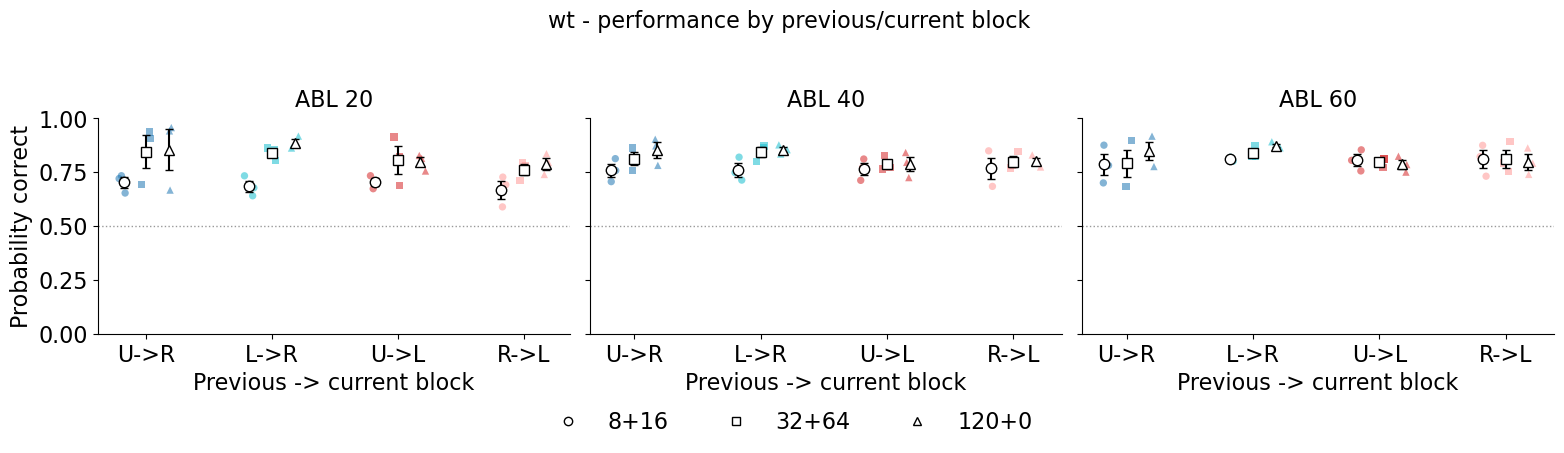

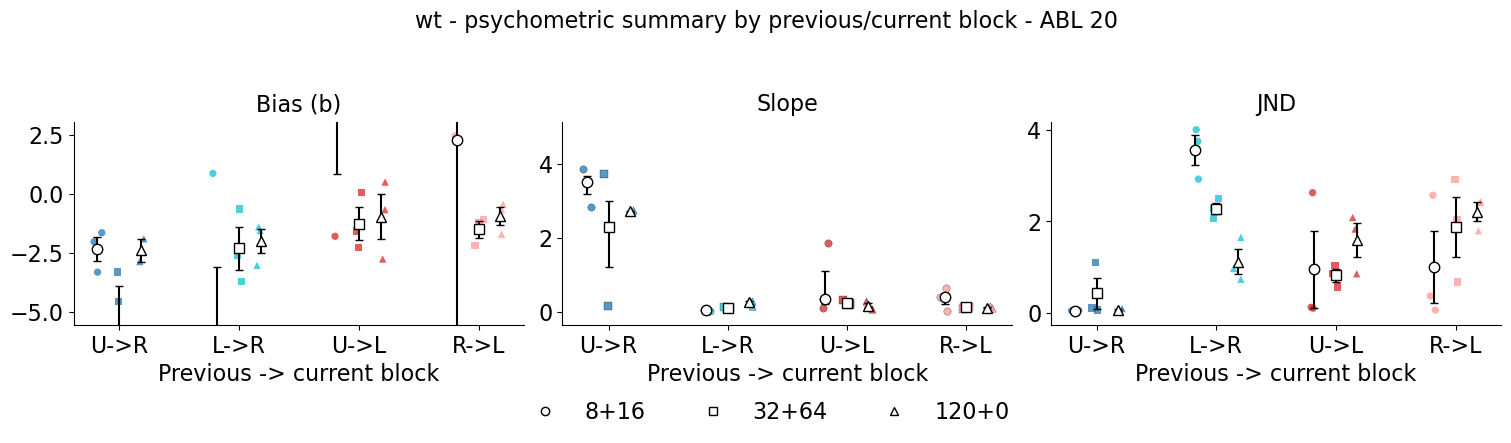

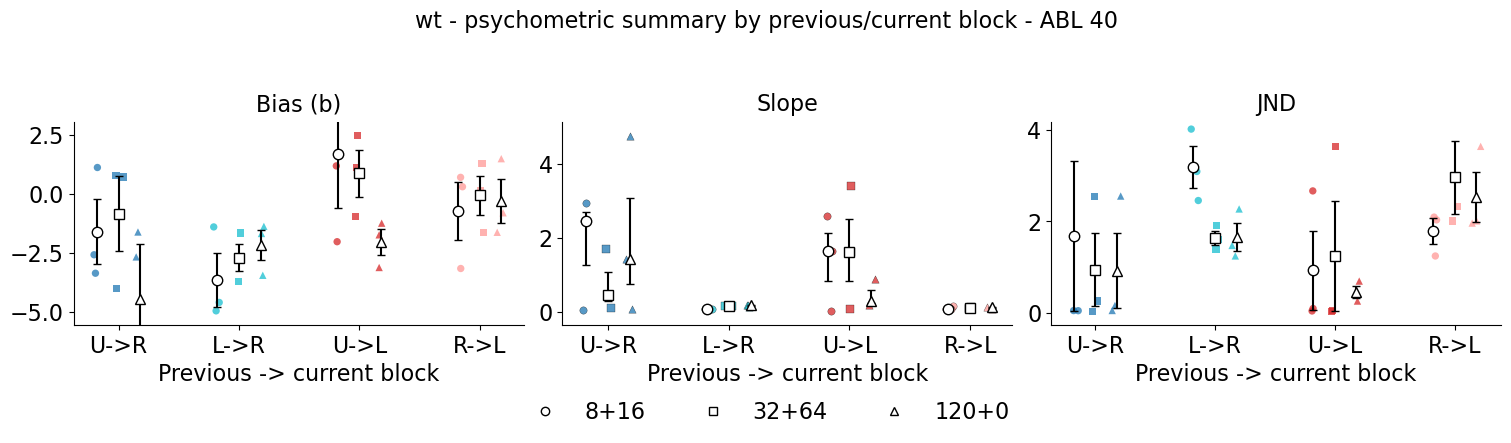

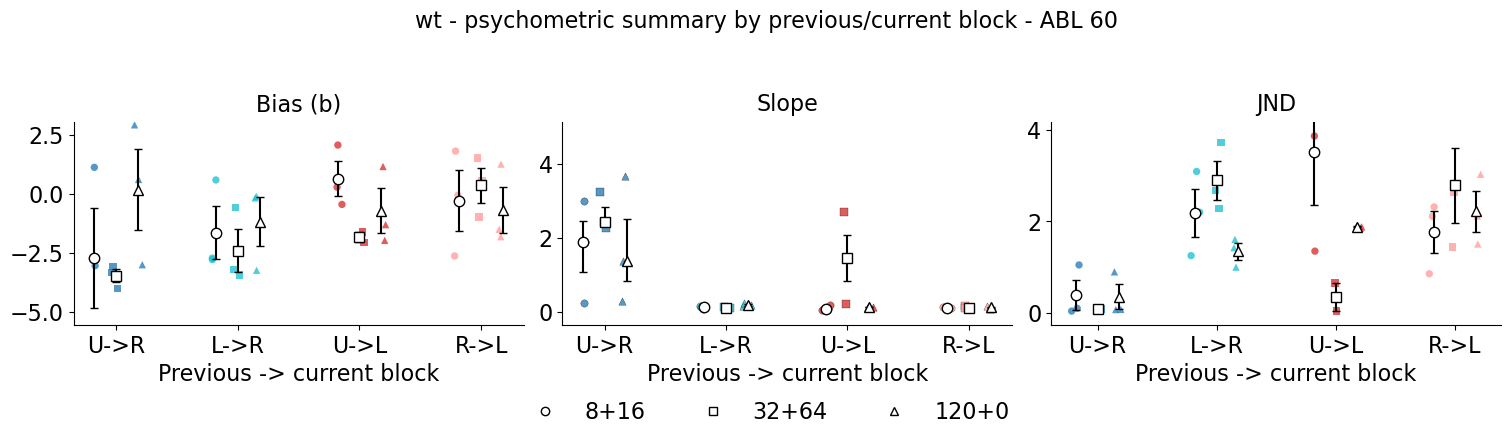

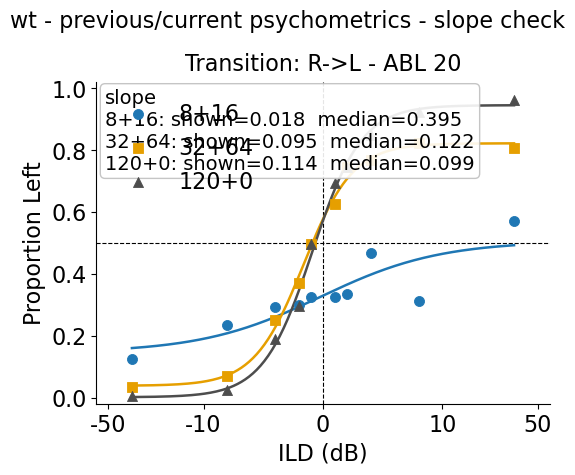

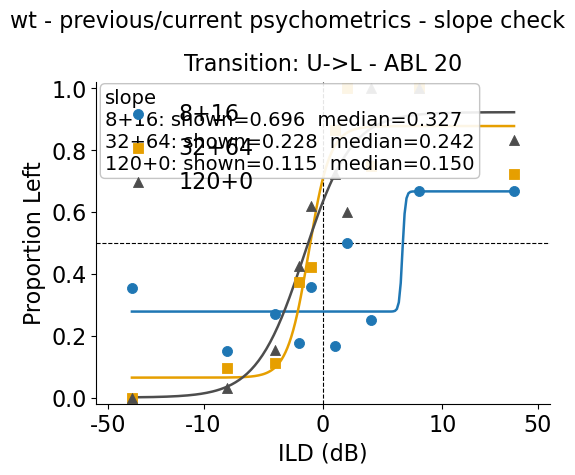

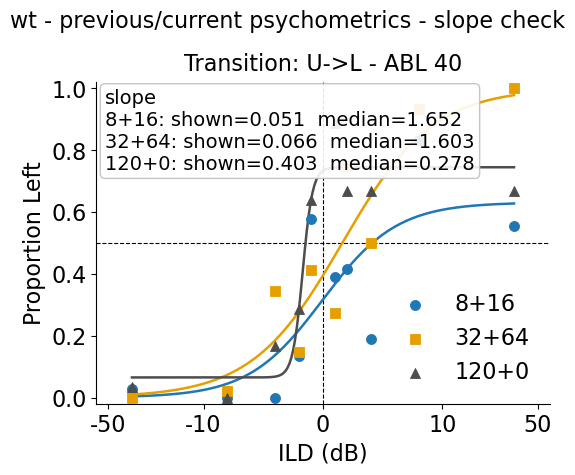

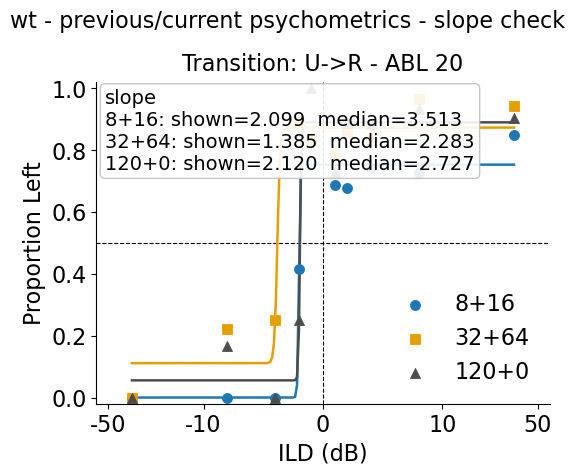

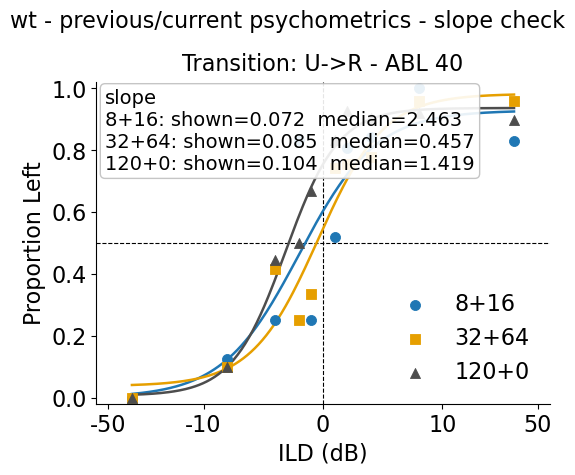

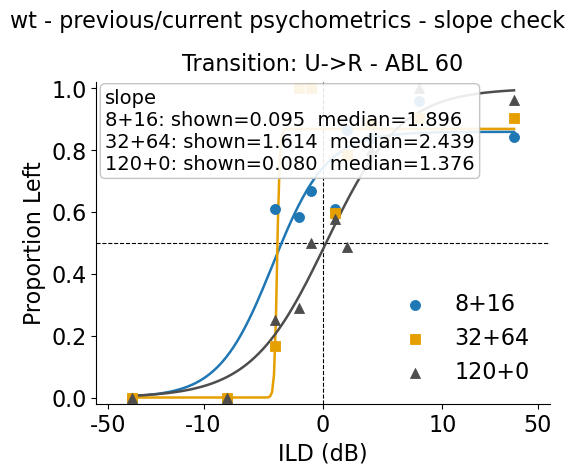

Previous/current suspicious slope values


,condition_type,condition,ABL,duration_pair,slope_metric,slope_summary,slope_summary_type,n_animals_with_slope,used_trimmed_mean
0,transition_type,R->L,20,8+16,effective_slope,0.395160,median,3,<NA>
1,transition_type,R->L,20,8+16,displayed_curve_slope,0.018039,displayed_curve,<NA>,<NA>
2,transition_type,R->L,20,32+64,effective_slope,0.121505,median,3,<NA>
3,transition_type,R->L,20,32+64,displayed_curve_slope,0.094788,displayed_curve,<NA>,<NA>
4,transition_type,R->L,20,120+0,effective_slope,0.099287,median,3,<NA>
5,transition_type,R->L,20,120+0,displayed_curve_slope,0.114484,displayed_curve,<NA>,<NA>
6,transition_type,U->L,20,8+16,effective_slope,0.326853,median,3,<NA>
7,transition_type,U->L,20,8+16,displayed_curve_slope,0.696317,displayed_curve,<NA>,<NA>
8,transition_type,U->L,20,32+64,effective_slope,0.241764,median,3,<NA>
9,transition_type,U->L,20,32+64,displayed_curve_slope,0.227907,displayed_curve,<NA>,<NA>


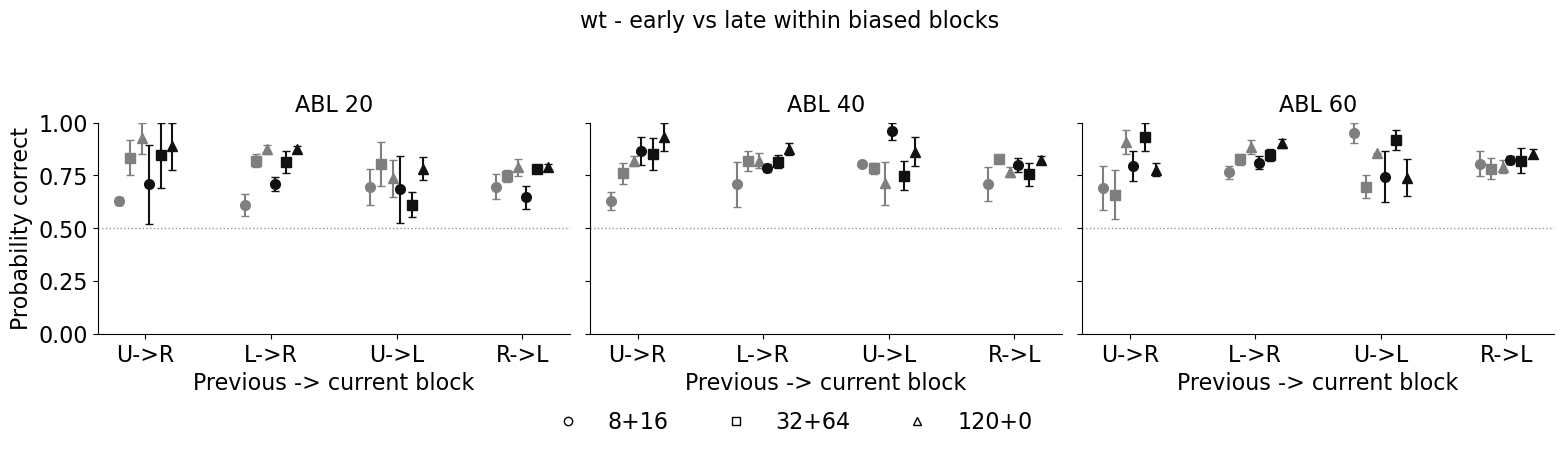

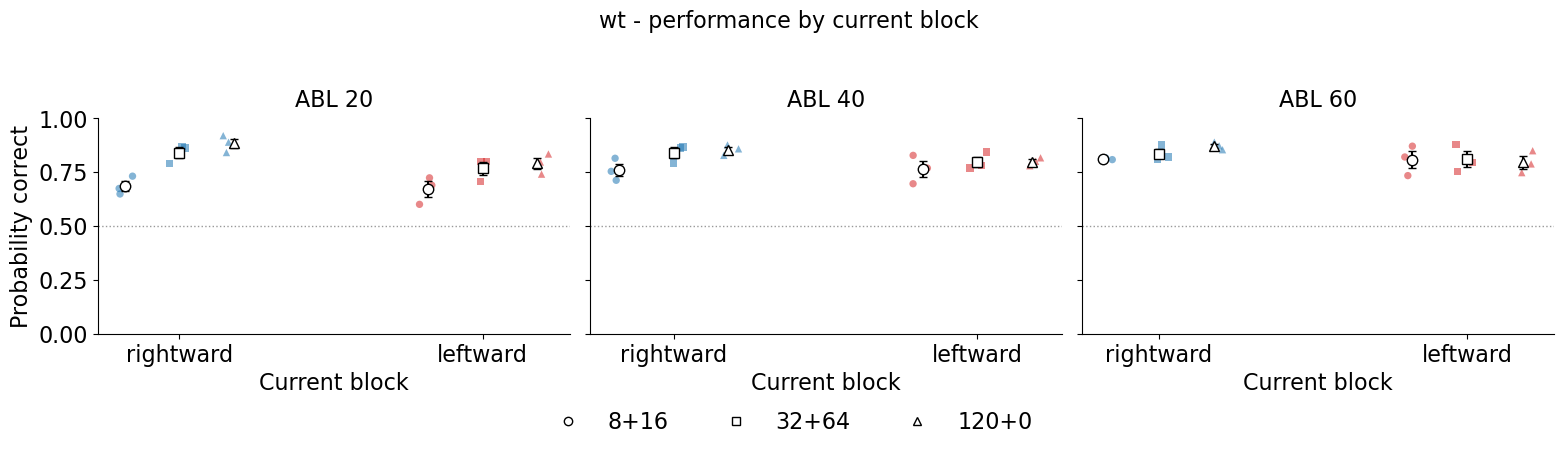

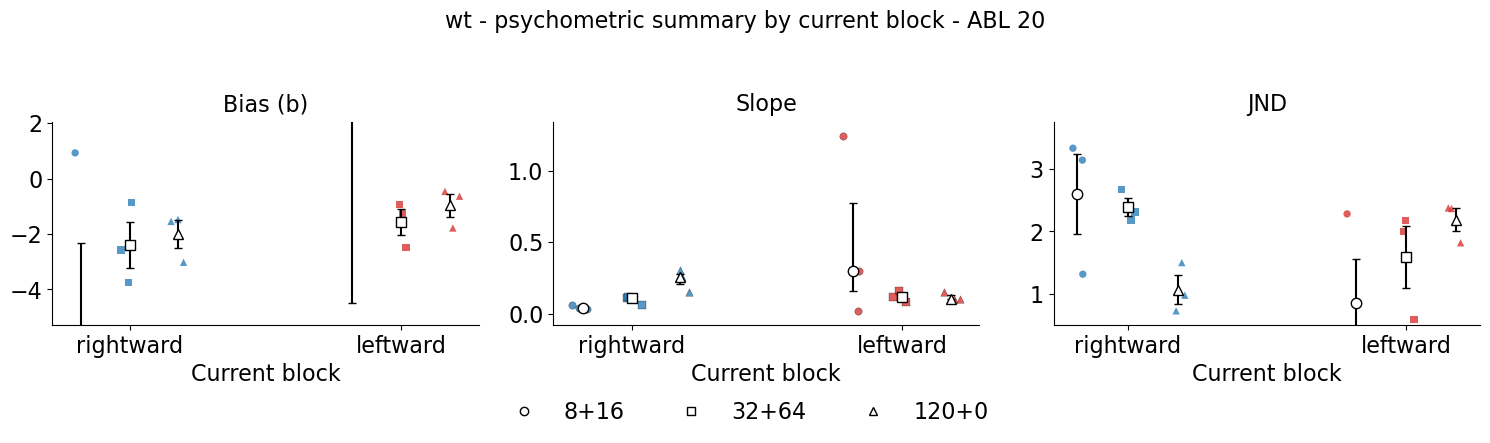

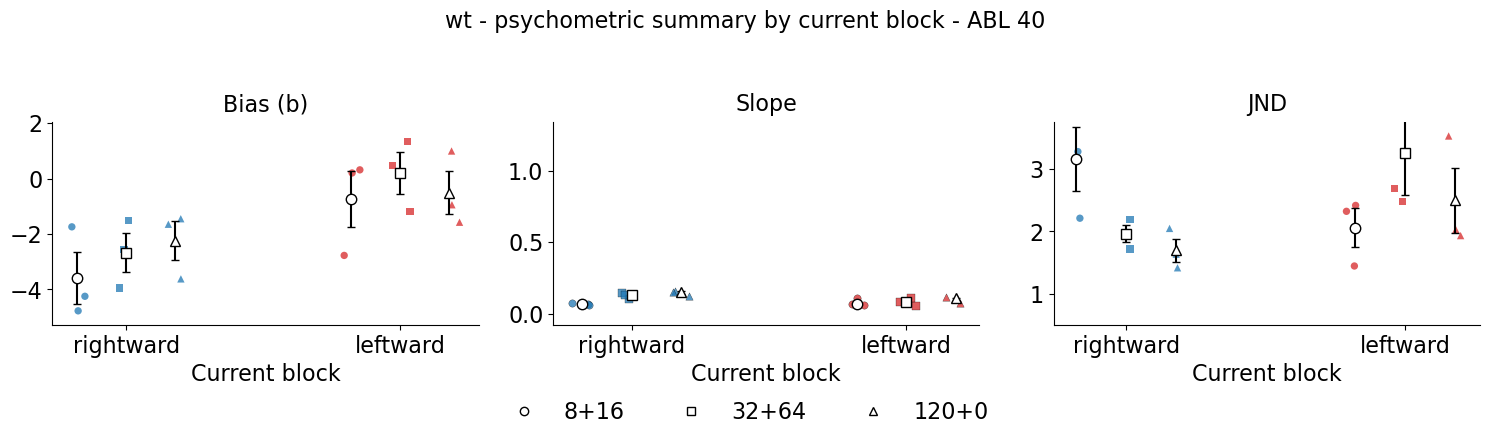

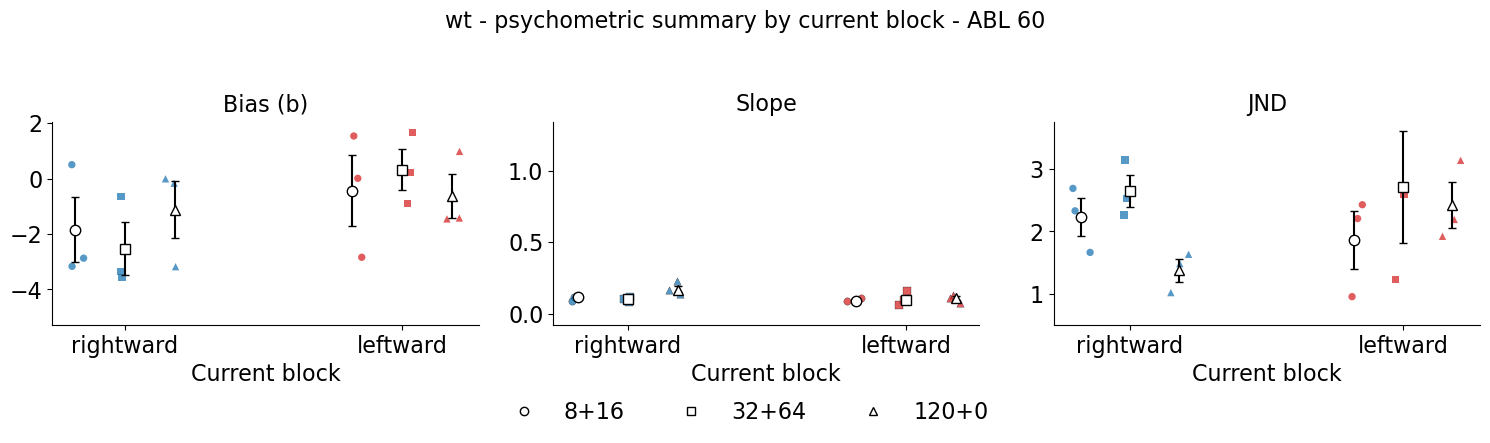

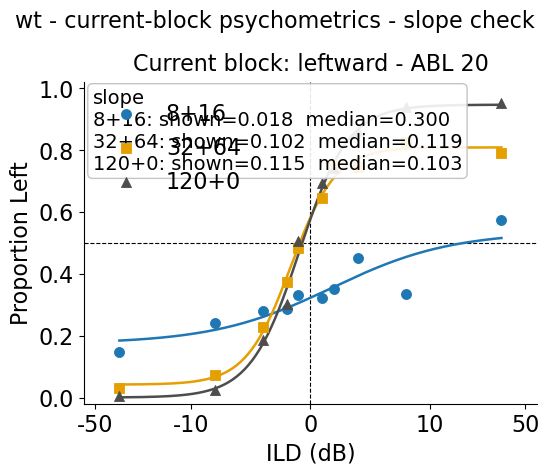

Current-block suspicious slope values


,condition_type,condition,ABL,duration_pair,slope_metric,slope_summary,slope_summary_type,n_animals_with_slope,used_trimmed_mean
0,current_block_condition,leftward,20,8+16,effective_slope,0.300128,median,3,<NA>
1,current_block_condition,leftward,20,8+16,displayed_curve_slope,0.018066,displayed_curve,<NA>,<NA>
2,current_block_condition,leftward,20,32+64,effective_slope,0.118781,median,3,<NA>
3,current_block_condition,leftward,20,32+64,displayed_curve_slope,0.102046,displayed_curve,<NA>,<NA>
4,current_block_condition,leftward,20,120+0,effective_slope,0.103312,median,3,<NA>
5,current_block_condition,leftward,20,120+0,displayed_curve_slope,0.115193,displayed_curve,<NA>,<NA>


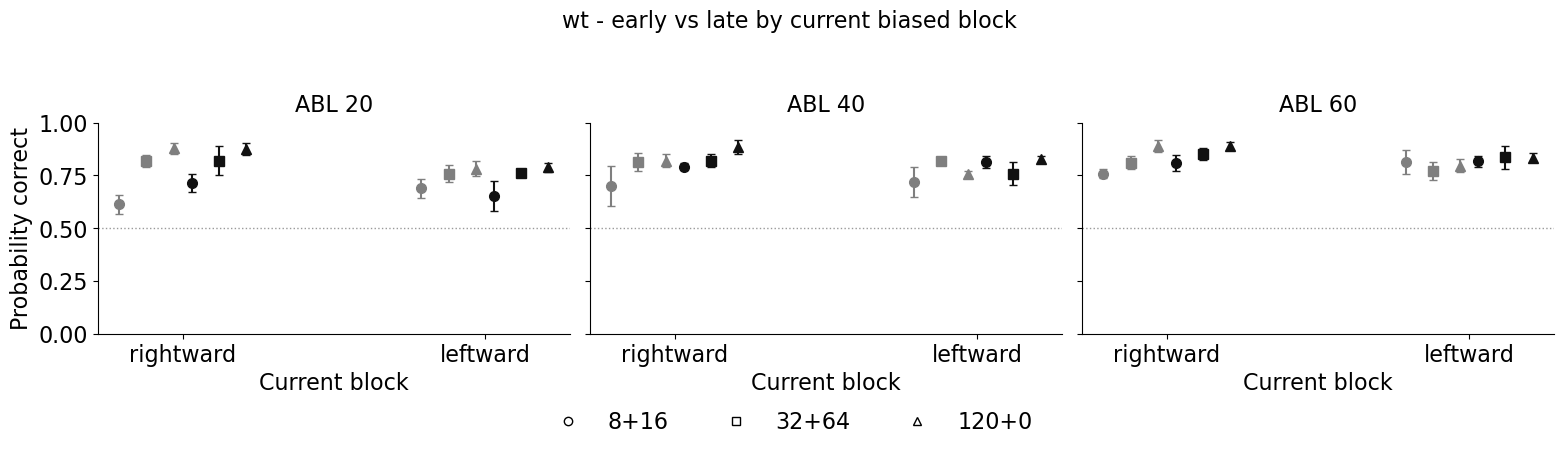

het {'performance_figure': 'ok', 'phase_figure': 'ok', 'psy_param_figures': ['ABL_20', 'ABL_40', 'ABL_60'], 'diagnostic_psychometric_figures': ['U->L_ABL_20', 'U->L_ABL_60', 'U->R_ABL_20', 'U->R_ABL_40', 'U->R_ABL_60'], 'current_performance_figure': 'ok', 'current_phase_figure': 'ok', 'current_psy_param_figures': ['ABL_20', 'ABL_40', 'ABL_60'], 'current_diagnostic_psychometric_figures': ['rightward_ABL_20']}


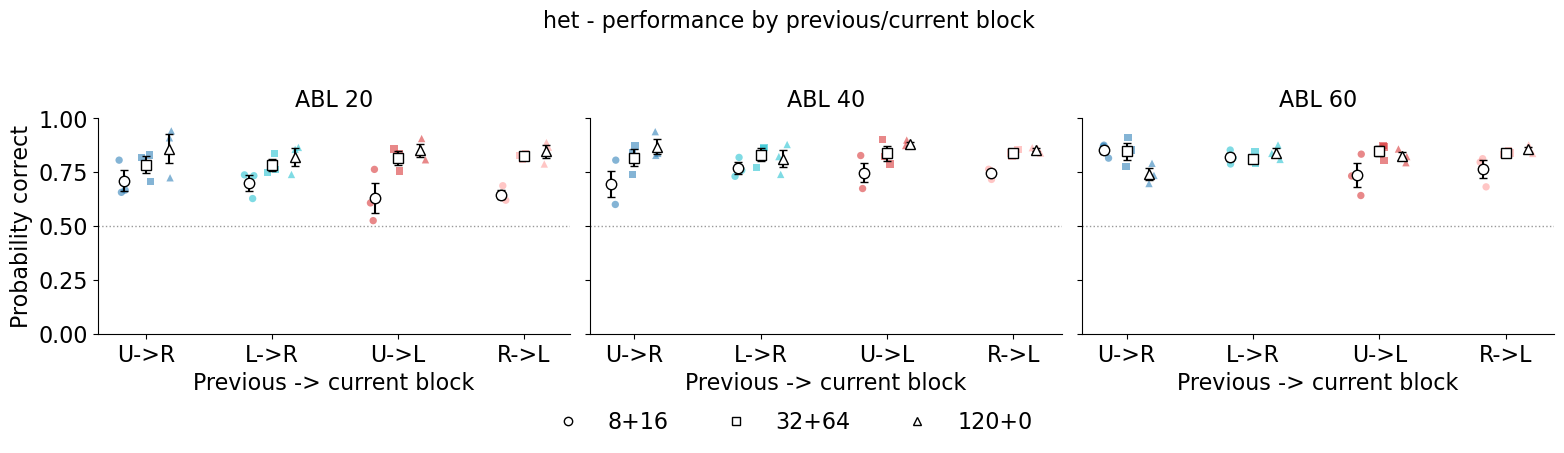

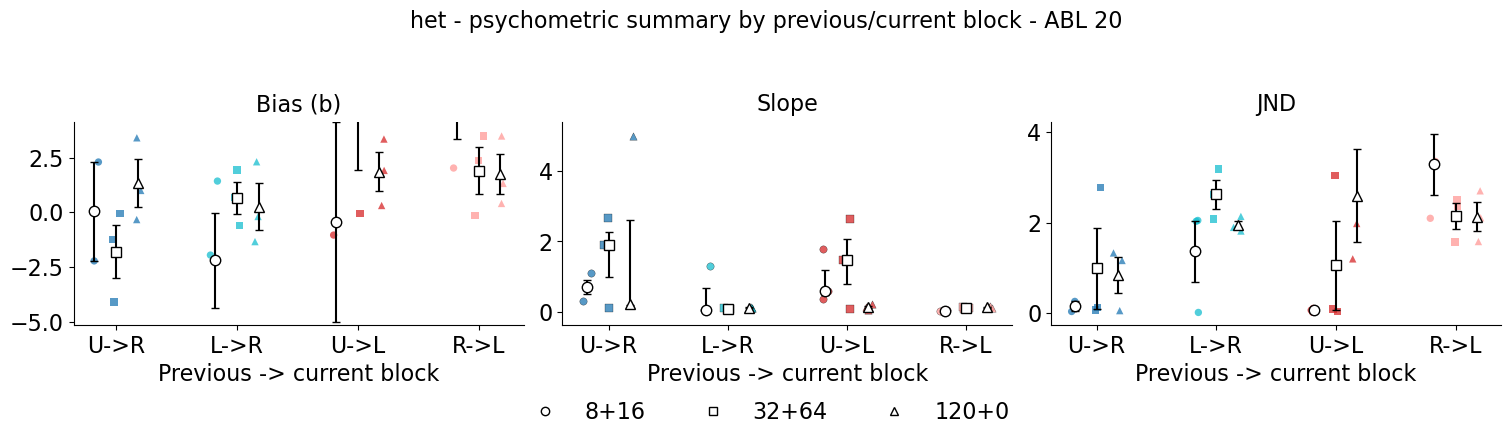

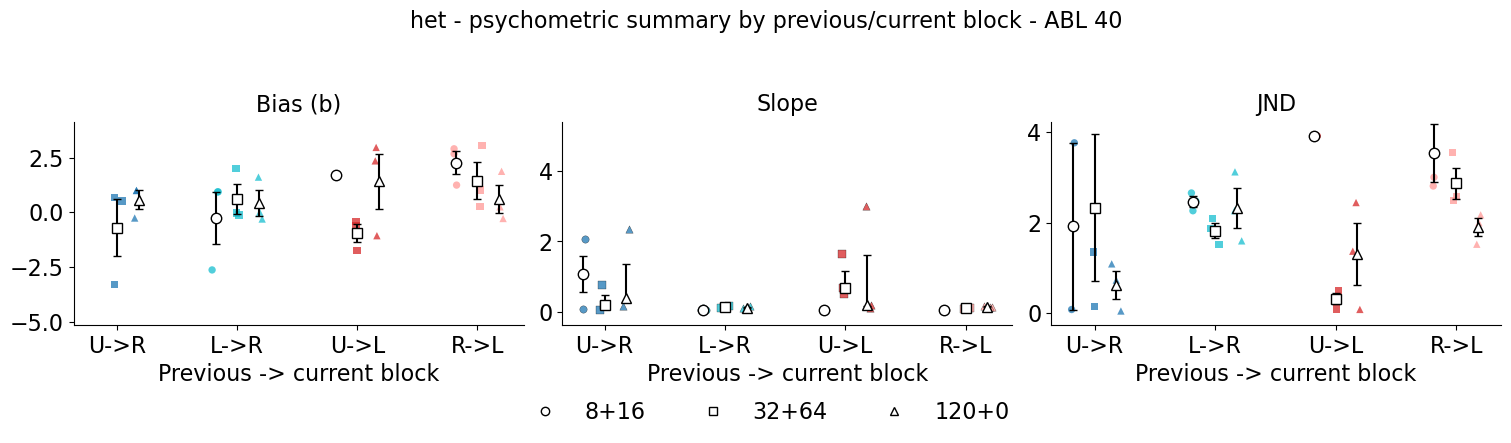

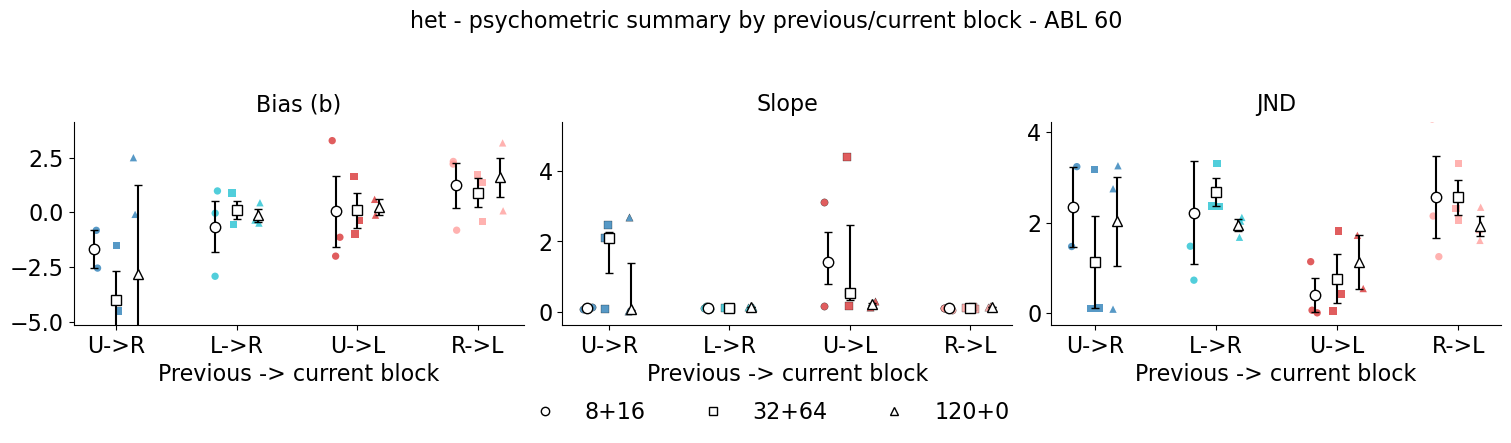

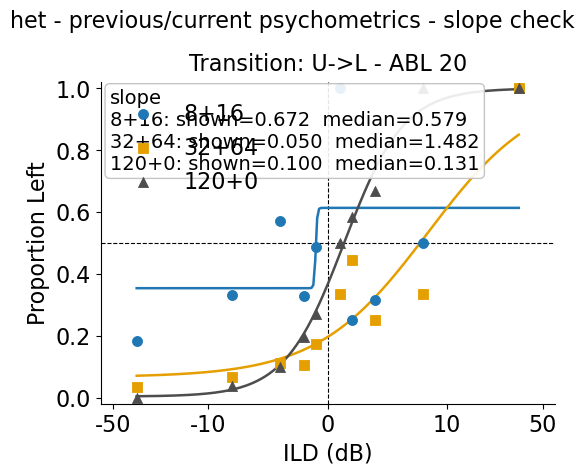

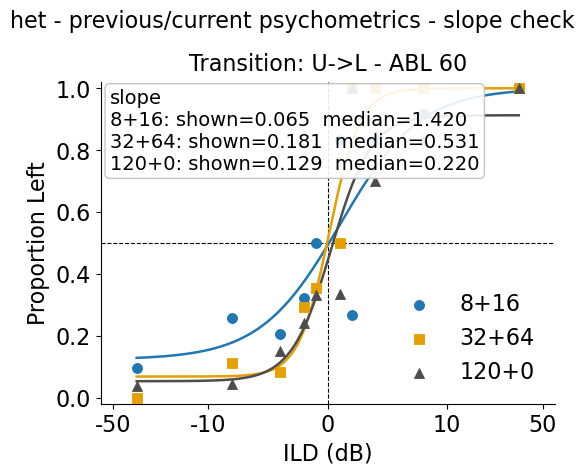

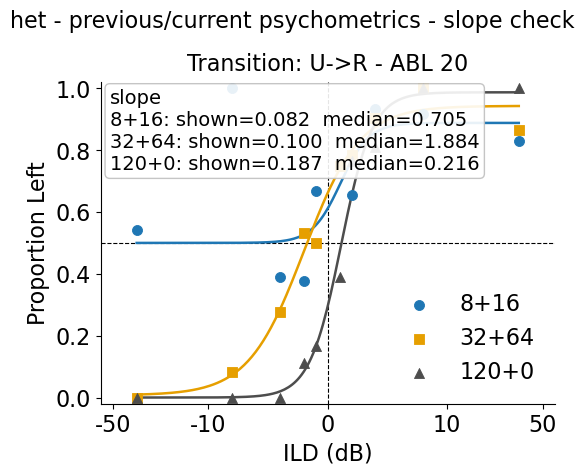

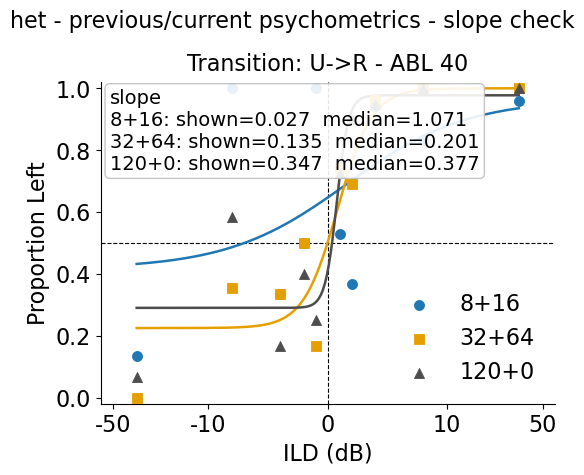

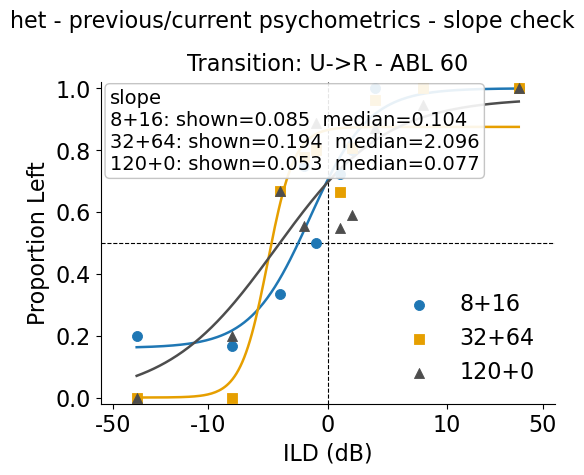

Previous/current suspicious slope values


,condition_type,condition,ABL,duration_pair,slope_metric,slope_summary,slope_summary_type,n_animals_with_slope,used_trimmed_mean
0,transition_type,U->L,20,8+16,effective_slope,0.579127,median,3,<NA>
1,transition_type,U->L,20,8+16,displayed_curve_slope,0.671832,displayed_curve,<NA>,<NA>
2,transition_type,U->L,20,32+64,effective_slope,1.481696,median,3,<NA>
3,transition_type,U->L,20,32+64,displayed_curve_slope,0.049581,displayed_curve,<NA>,<NA>
4,transition_type,U->L,20,120+0,effective_slope,0.130985,median,3,<NA>
5,transition_type,U->L,20,120+0,displayed_curve_slope,0.099999,displayed_curve,<NA>,<NA>
6,transition_type,U->L,60,8+16,effective_slope,1.420399,median,3,<NA>
7,transition_type,U->L,60,8+16,displayed_curve_slope,0.065409,displayed_curve,<NA>,<NA>
8,transition_type,U->L,60,32+64,effective_slope,0.530769,median,3,<NA>
9,transition_type,U->L,60,32+64,displayed_curve_slope,0.180843,displayed_curve,<NA>,<NA>


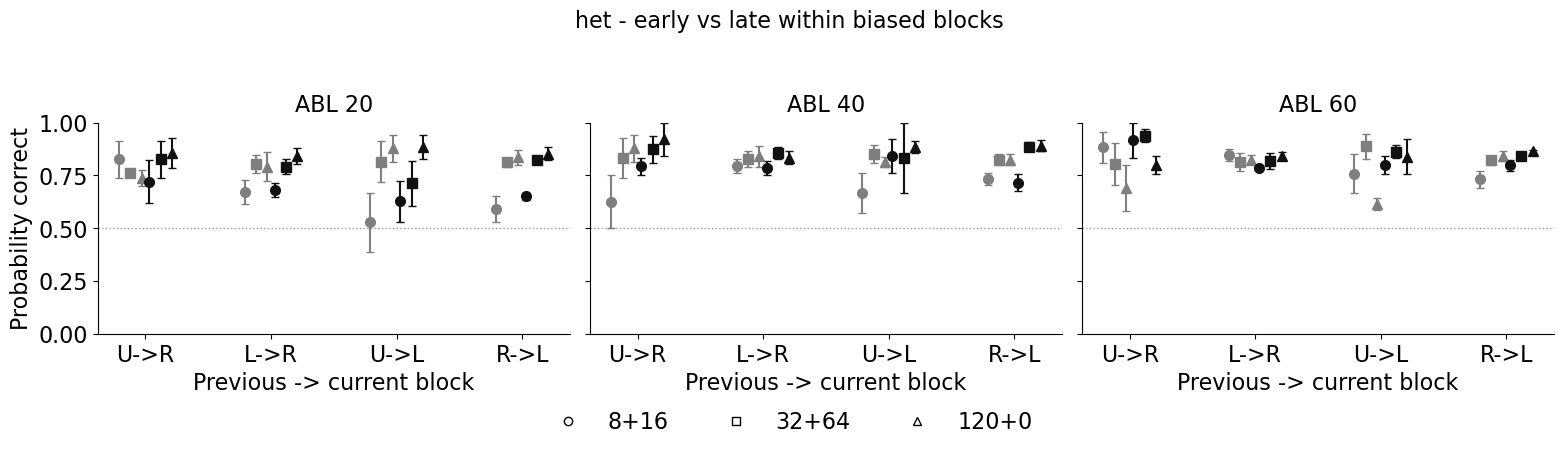

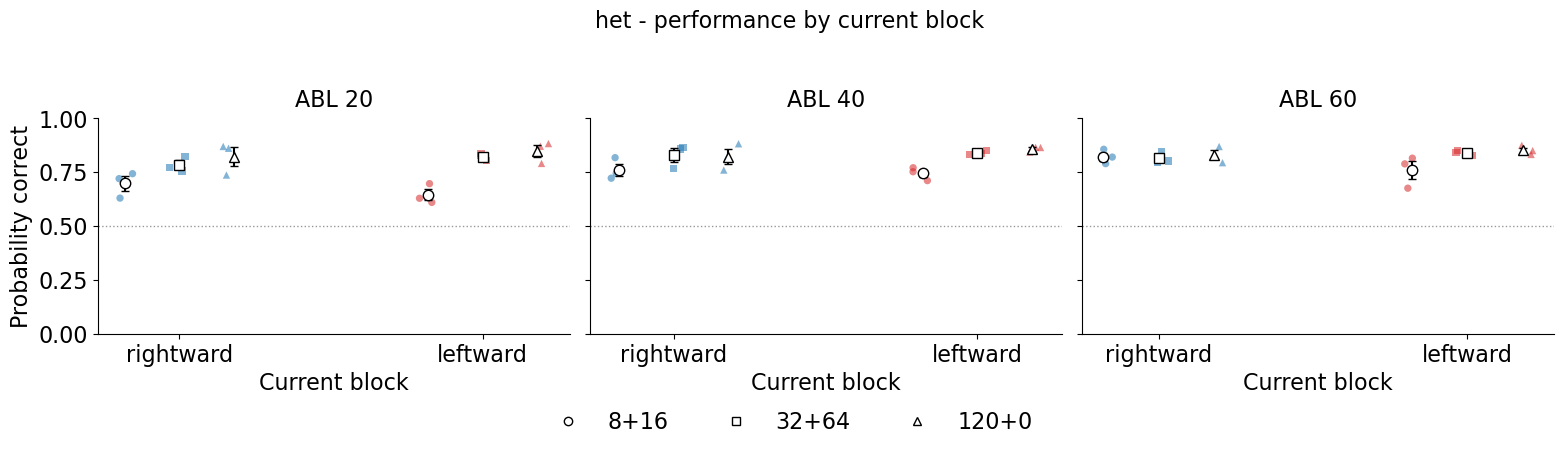

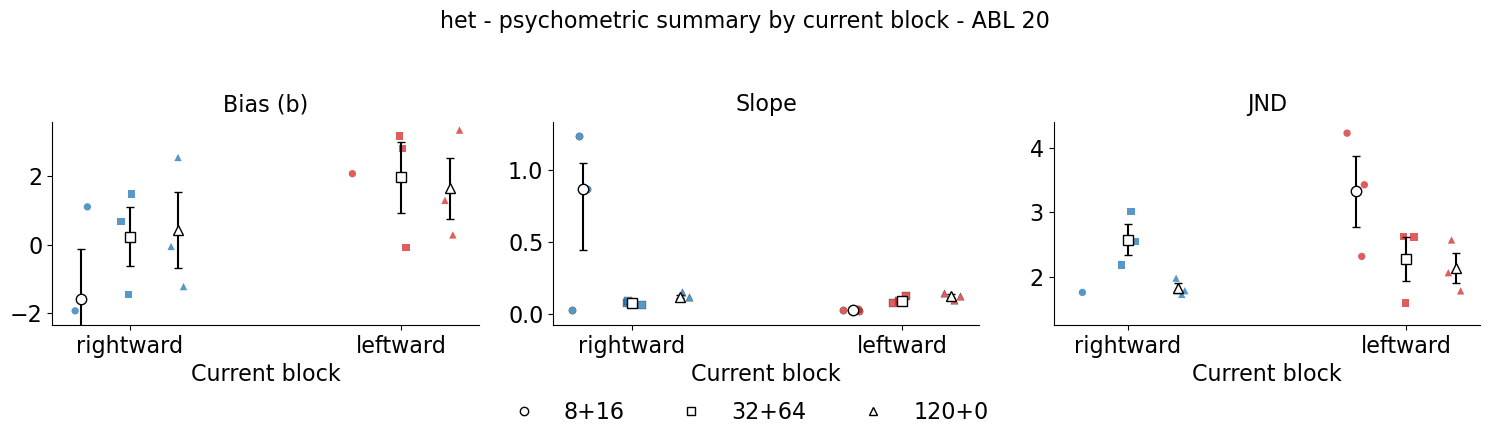

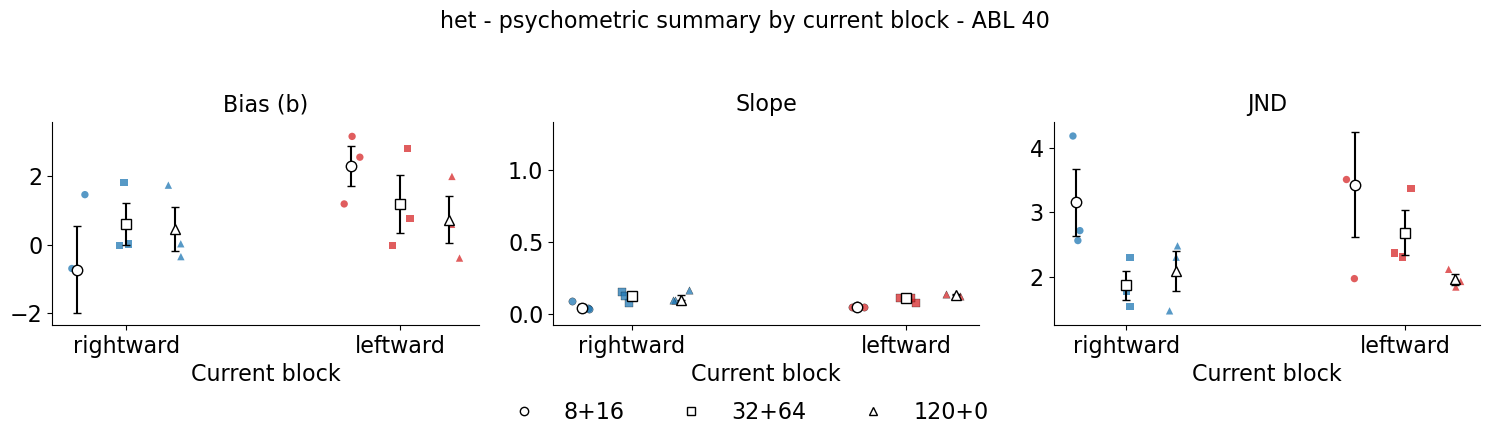

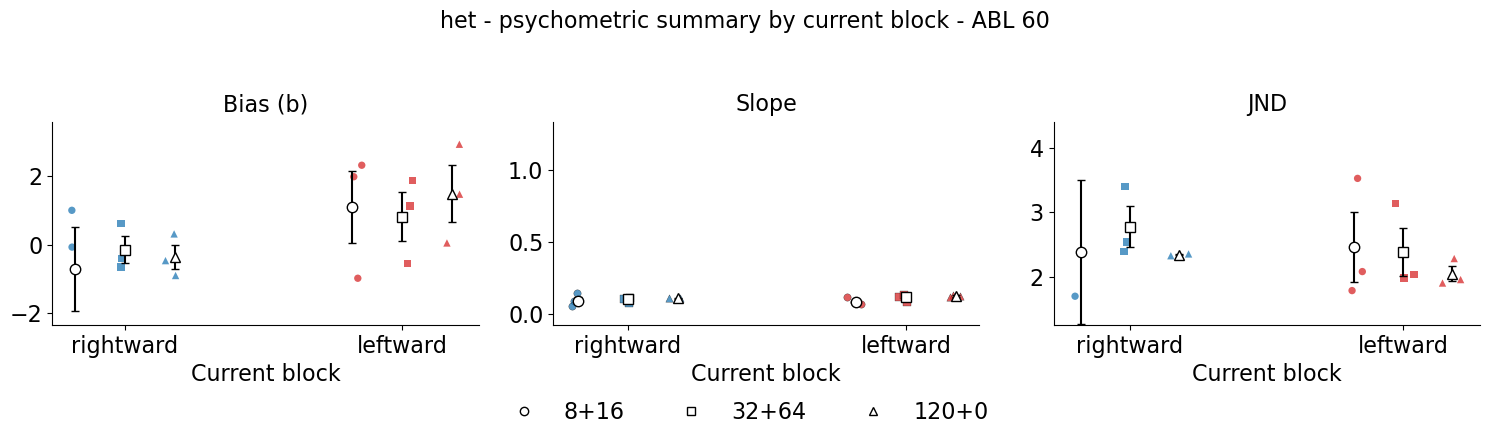

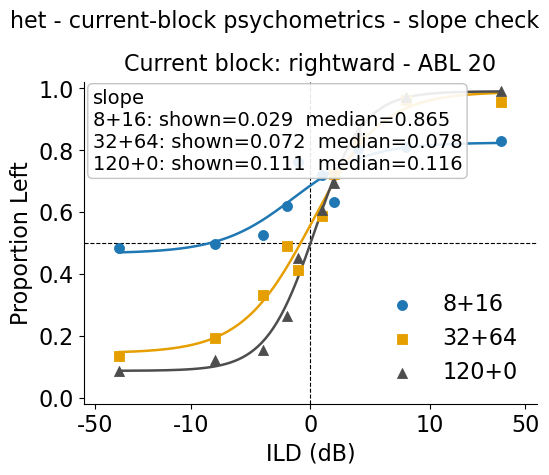

Current-block suspicious slope values


,condition_type,condition,ABL,duration_pair,slope_metric,slope_summary,slope_summary_type,n_animals_with_slope,used_trimmed_mean
0,current_block_condition,rightward,20,8+16,effective_slope,0.864815,median,3,<NA>
1,current_block_condition,rightward,20,8+16,displayed_curve_slope,0.029129,displayed_curve,<NA>,<NA>
2,current_block_condition,rightward,20,32+64,effective_slope,0.077539,median,3,<NA>
3,current_block_condition,rightward,20,32+64,displayed_curve_slope,0.072058,displayed_curve,<NA>,<NA>
4,current_block_condition,rightward,20,120+0,effective_slope,0.116390,median,3,<NA>
5,current_block_condition,rightward,20,120+0,displayed_curve_slope,0.111461,displayed_curve,<NA>,<NA>


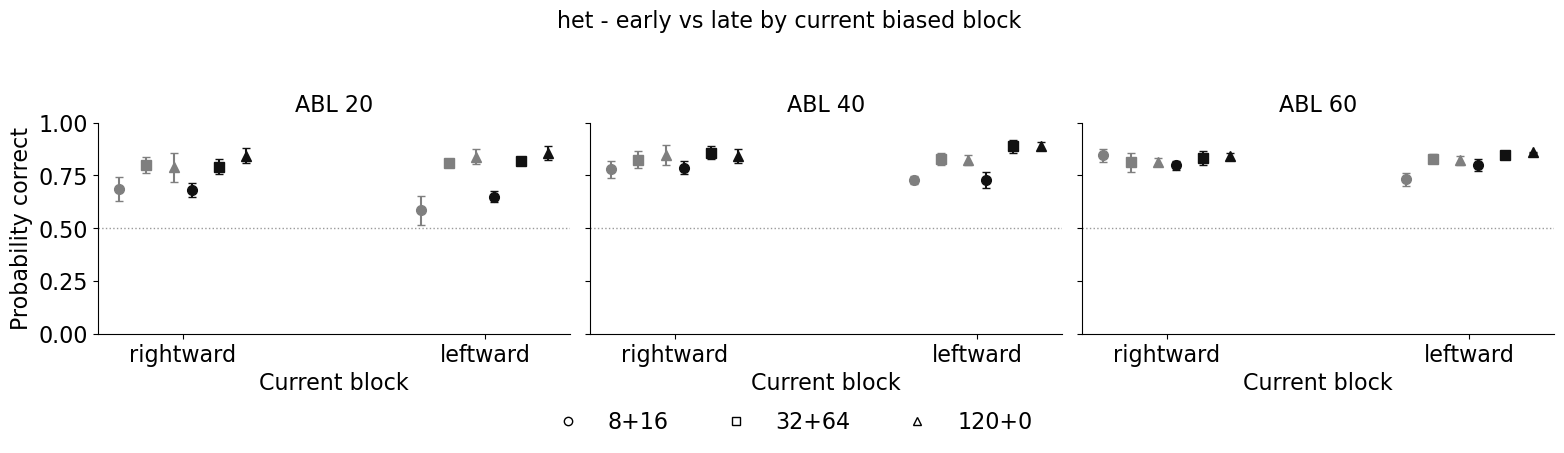

hom {'performance_figure': 'ok', 'phase_figure': 'ok', 'psy_param_figures': ['ABL_20', 'ABL_40', 'ABL_60'], 'diagnostic_psychometric_figures': ['L->R_ABL_60', 'R->L_ABL_60', 'U->L_ABL_20', 'U->L_ABL_40', 'U->L_ABL_60', 'U->R_ABL_20', 'U->R_ABL_40', 'U->R_ABL_60'], 'current_performance_figure': 'ok', 'current_phase_figure': 'ok', 'current_psy_param_figures': ['ABL_20', 'ABL_40', 'ABL_60'], 'current_diagnostic_psychometric_figures': ['leftward_ABL_20']}


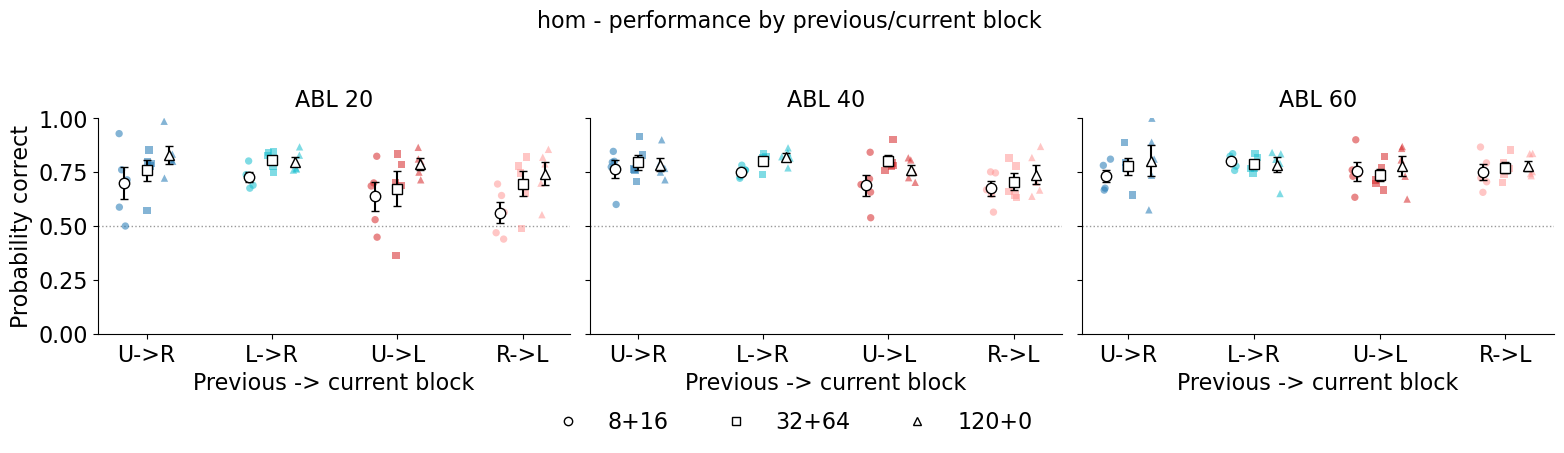

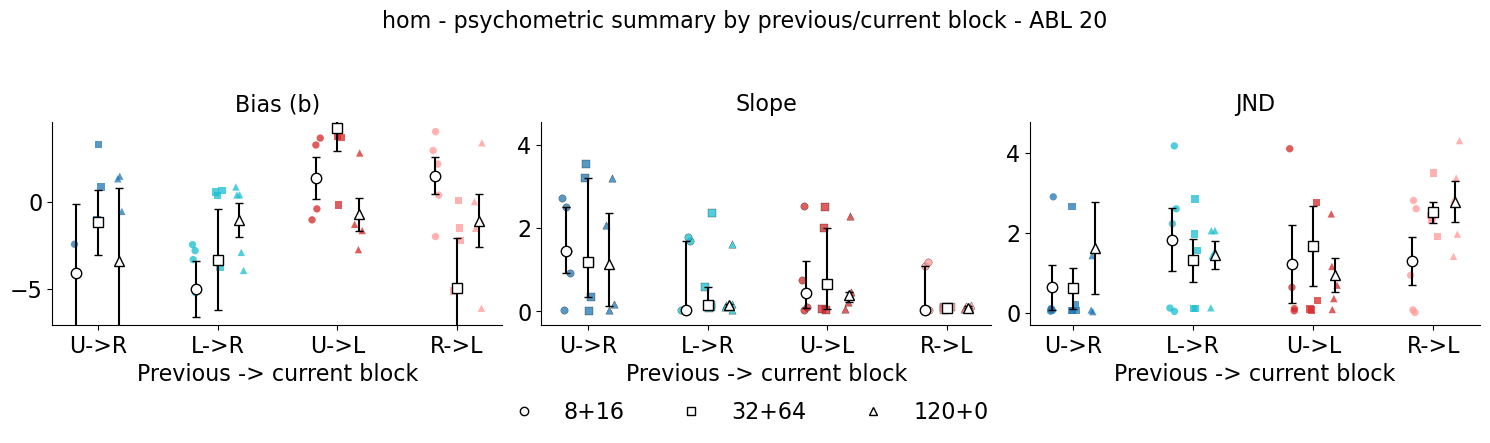

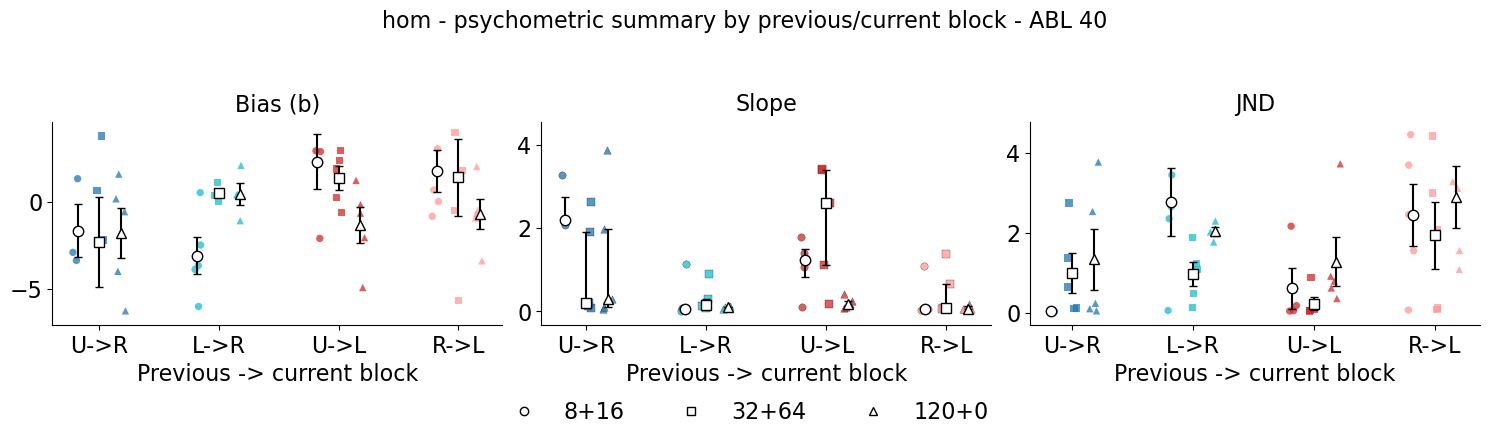

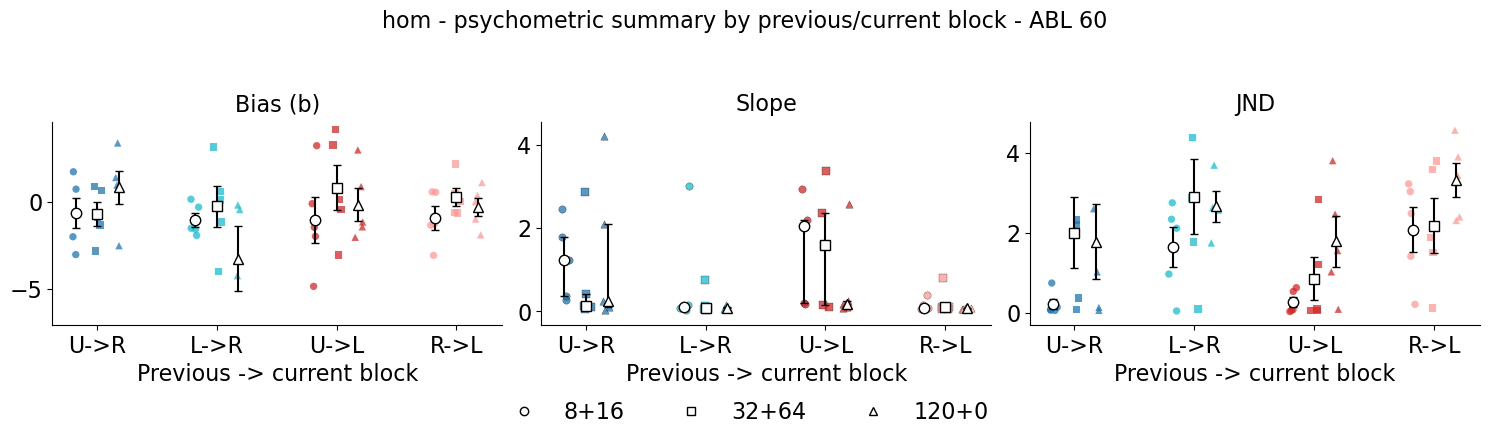

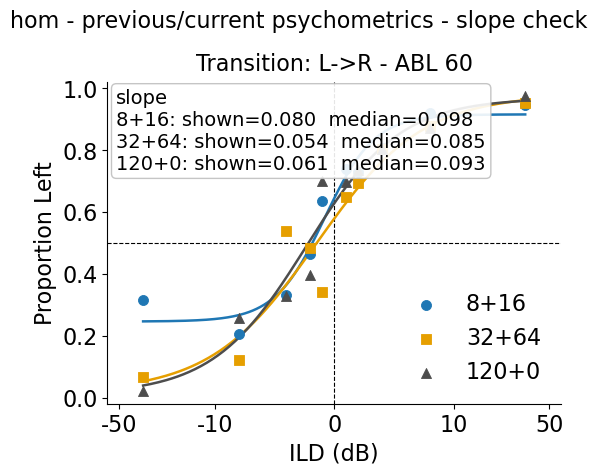

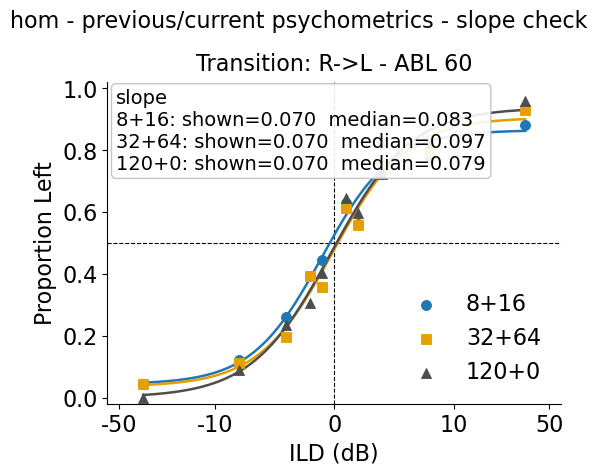

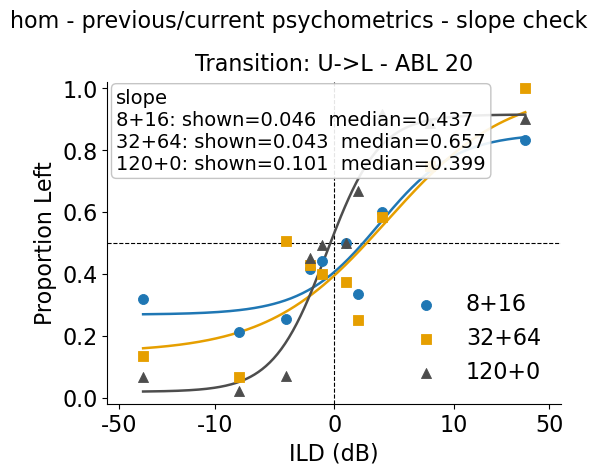

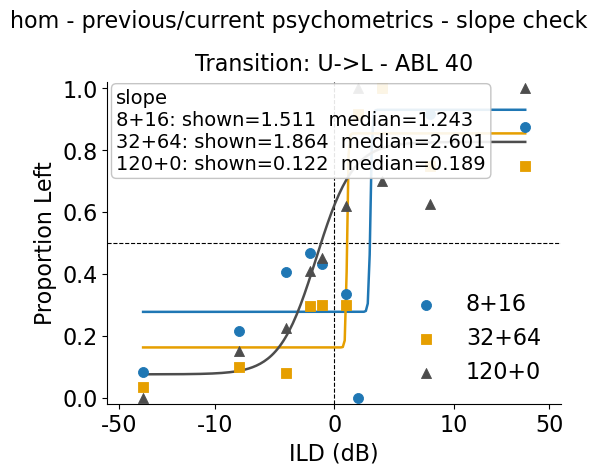

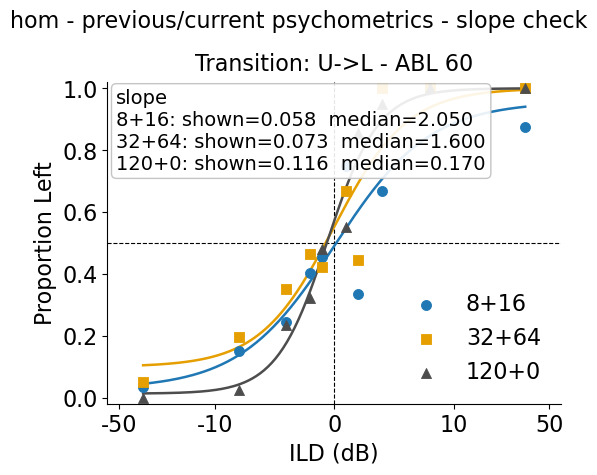

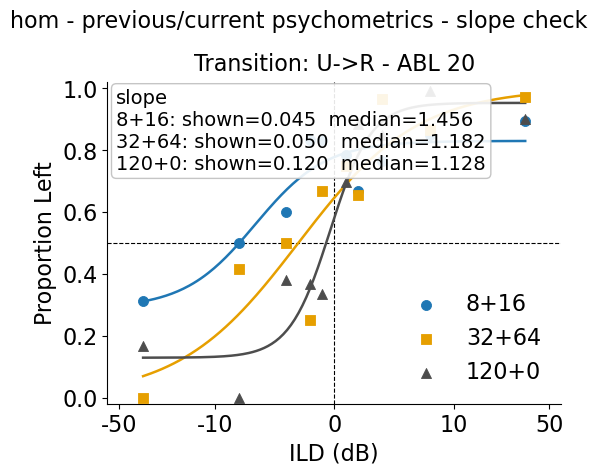

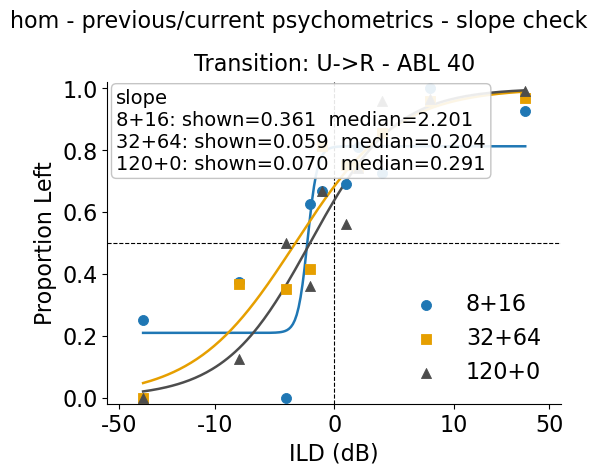

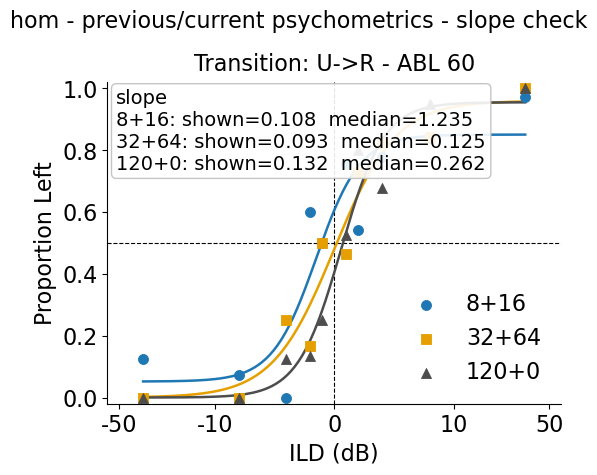

Previous/current suspicious slope values


,condition_type,condition,ABL,duration_pair,slope_metric,slope_summary,slope_summary_type,n_animals_with_slope,used_trimmed_mean
0,transition_type,L->R,60,8+16,effective_slope,0.098161,median,5,<NA>
1,transition_type,L->R,60,8+16,displayed_curve_slope,0.080132,displayed_curve,<NA>,<NA>
2,transition_type,L->R,60,32+64,effective_slope,0.085309,median,5,<NA>
3,transition_type,L->R,60,32+64,displayed_curve_slope,0.054243,displayed_curve,<NA>,<NA>
4,transition_type,L->R,60,120+0,effective_slope,0.092855,median,4,<NA>
5,transition_type,L->R,60,120+0,displayed_curve_slope,0.061041,displayed_curve,<NA>,<NA>
6,transition_type,R->L,60,8+16,effective_slope,0.083073,median,5,<NA>
7,transition_type,R->L,60,8+16,displayed_curve_slope,0.069780,displayed_curve,<NA>,<NA>
8,transition_type,R->L,60,32+64,effective_slope,0.096811,median,5,<NA>
9,transition_type,R->L,60,32+64,displayed_curve_slope,0.069876,displayed_curve,<NA>,<NA>


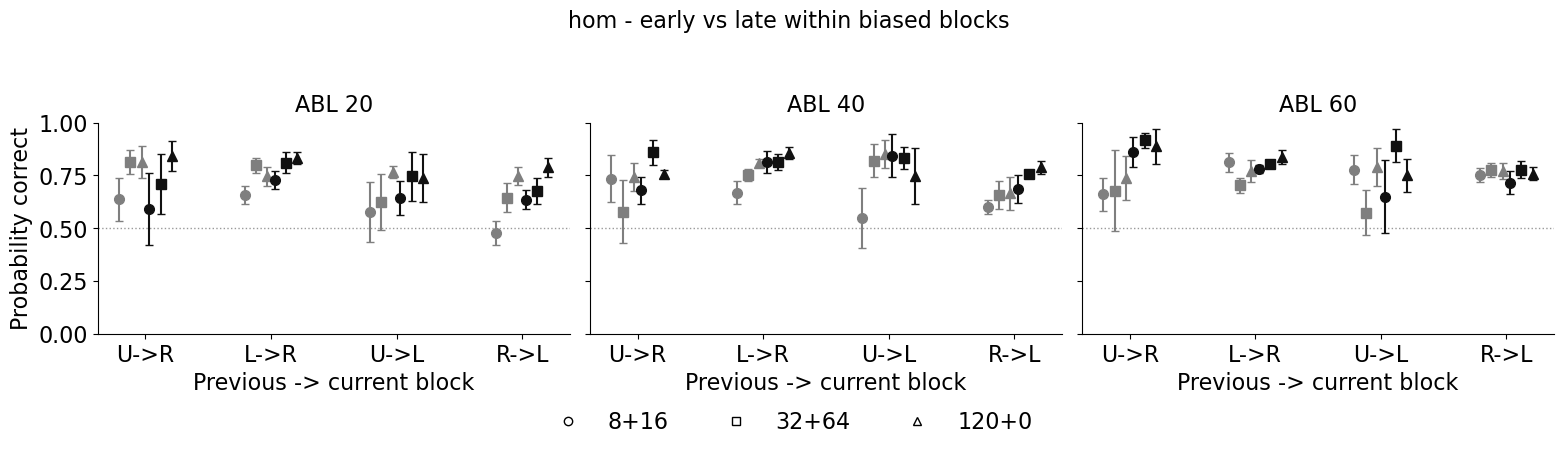

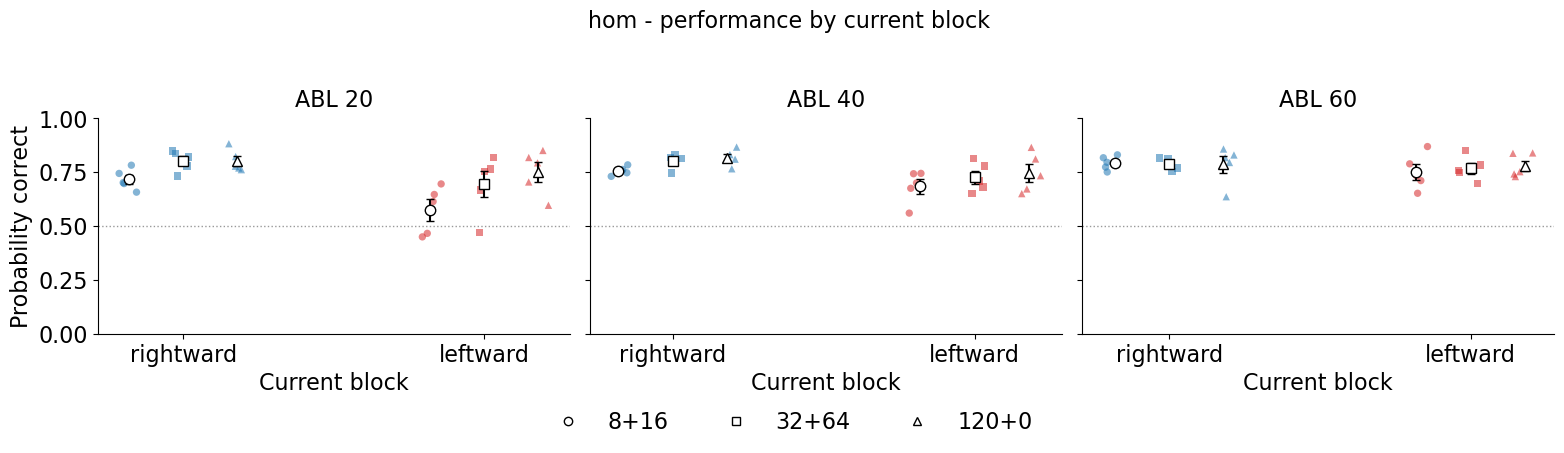

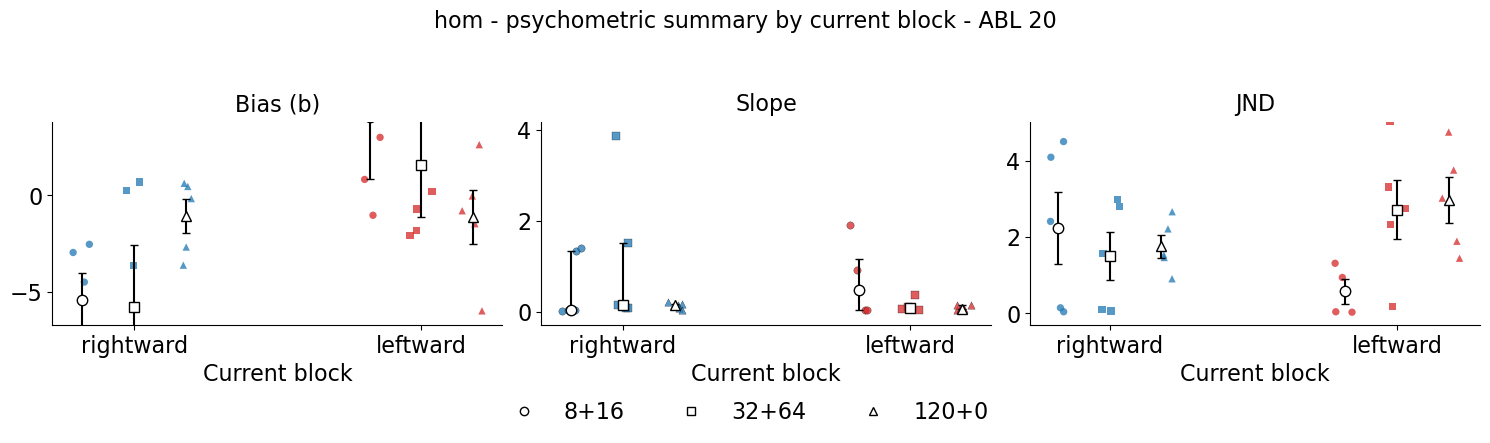

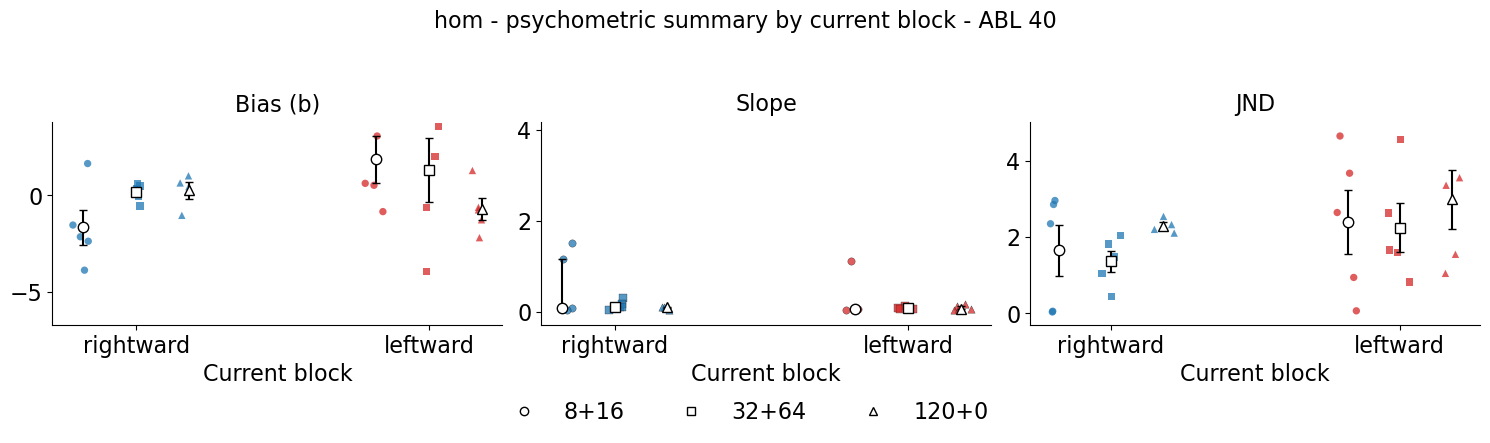

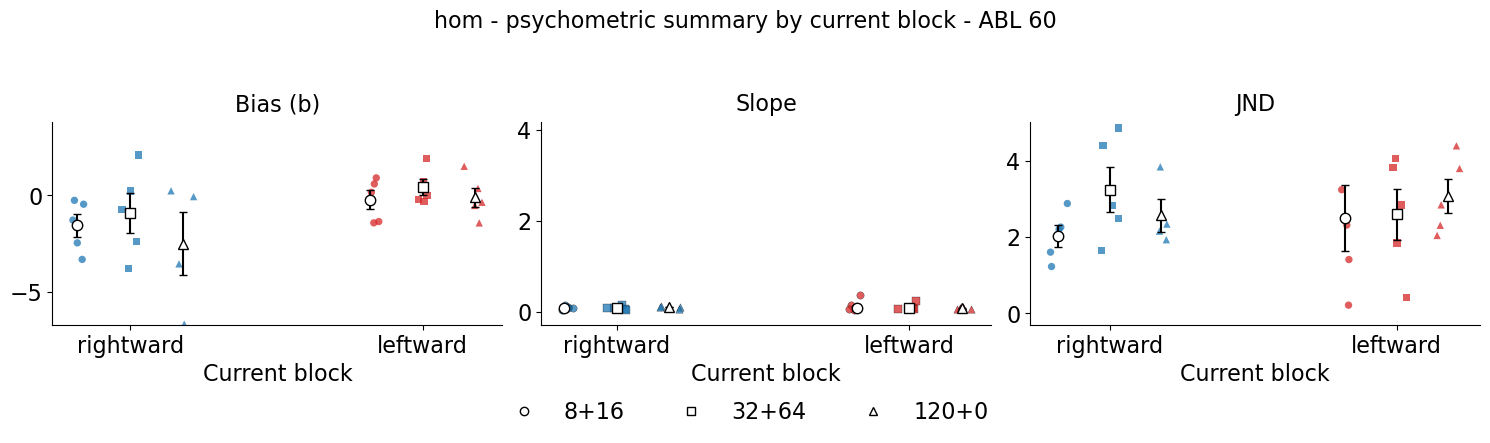

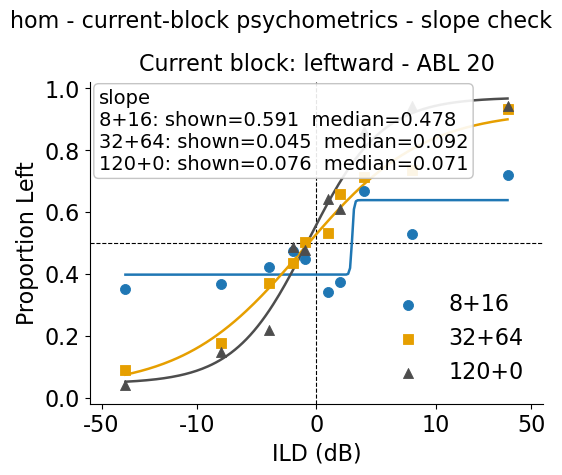

Current-block suspicious slope values


,condition_type,condition,ABL,duration_pair,slope_metric,slope_summary,slope_summary_type,n_animals_with_slope,used_trimmed_mean
0,current_block_condition,leftward,20,8+16,effective_slope,0.477795,median,4,<NA>
1,current_block_condition,leftward,20,8+16,displayed_curve_slope,0.591177,displayed_curve,<NA>,<NA>
2,current_block_condition,leftward,20,32+64,effective_slope,0.092337,median,5,<NA>
3,current_block_condition,leftward,20,32+64,displayed_curve_slope,0.044852,displayed_curve,<NA>,<NA>
4,current_block_condition,leftward,20,120+0,effective_slope,0.071275,median,5,<NA>
5,current_block_condition,leftward,20,120+0,displayed_curve_slope,0.075633,displayed_curve,<NA>,<NA>


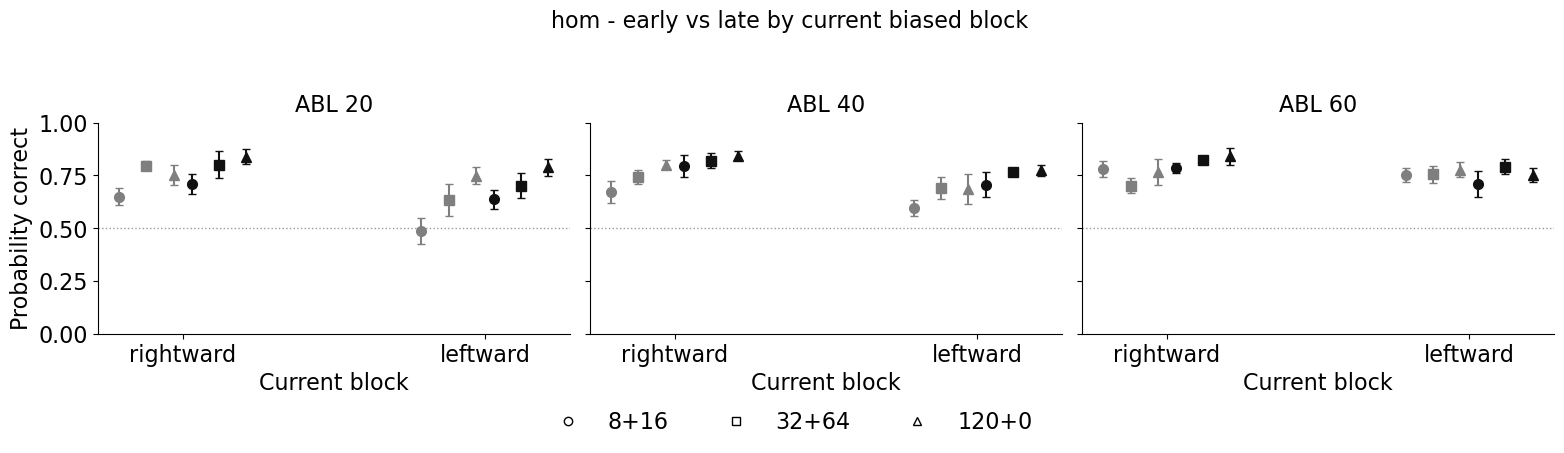

history figures rendered


In [9]:
import importlib
import matplotlib.pyplot as plt
from IPython.display import display

bb = importlib.reload(bb)

def figure_signature(fig):
    suptitle = fig._suptitle.get_text() if getattr(fig, '_suptitle', None) is not None else ''
    axes_bits = []
    for ax in fig.axes:
        axes_bits.append((
            ax.get_title(),
            ax.get_xlabel(),
            ax.get_ylabel(),
            tuple(t.get_text() for t in ax.get_xticklabels()),
            tuple(t.get_text() for t in ax.get_yticklabels()),
            len(ax.lines),
            len(ax.collections),
        ))
    return (suptitle, tuple(axes_bits))

seen_figure_signatures = set()

def display_and_close(fig):
    sig = figure_signature(fig)
    if sig in seen_figure_signatures:
        plt.close(fig)
        return
    seen_figure_signatures.add(sig)
    display(fig)
    plt.close(fig)

HISTORY_PLOT_VIEW = None      # set to a view name to plot just one selected group/view
HISTORY_ABLS = (20, 40, 60)
HISTORY_EARLY_N = 10         # first N valid trials in the current biased block
HISTORY_LATE_N = 10          # last N valid trials in the current biased block
HISTORY_DURATION_GROUPS = ((8, 16), (32, 64), (120, 0))

history_views = [v for v in views if HISTORY_PLOT_VIEW is None or v.name == HISTORY_PLOT_VIEW]
if not history_views:
    raise ValueError(f"HISTORY_PLOT_VIEW={HISTORY_PLOT_VIEW!r} did not match any selected view.")

plt.close('all')

with plt.ioff():
    history_out = bb.plot_block_history_exploration(
        bundle=bundle,
        views=history_views,
        abls=HISTORY_ABLS,
        early_n=HISTORY_EARLY_N,
        late_n=HISTORY_LATE_N,
        duration_groups=HISTORY_DURATION_GROUPS,
        show=False,
    )

for view_name, payload in history_out.items():
    print(view_name, payload.get("status", {}))
    if payload.get("performance_figure") is not None:
        display_and_close(payload["performance_figure"])
    for fig in payload.get("psy_param_figures", {}).values():
        display_and_close(fig)
    for fig in payload.get("diagnostic_psychometric_figures", {}).values():
        display_and_close(fig)
    if payload.get("diagnostic_slope_table") is not None and not payload["diagnostic_slope_table"].empty:
        print("Previous/current suspicious slope values")
        display(payload["diagnostic_slope_table"])
    if payload.get("phase_figure") is not None:
        display_and_close(payload["phase_figure"])
    if payload.get("current_performance_figure") is not None:
        display_and_close(payload["current_performance_figure"])
    for fig in payload.get("current_psy_param_figures", {}).values():
        display_and_close(fig)
    for fig in payload.get("current_diagnostic_psychometric_figures", {}).values():
        display_and_close(fig)
    if payload.get("current_diagnostic_slope_table") is not None and not payload["current_diagnostic_slope_table"].empty:
        print("Current-block suspicious slope values")
        display(payload["current_diagnostic_slope_table"])
    if payload.get("current_phase_figure") is not None:
        display_and_close(payload["current_phase_figure"])

plt.close('all')
print("history figures rendered")


## 9. Experimental Fit Check

In [ ]:
import contextlib
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis import psychometric as Psychometric
from GroupComparison.prepare import prep_psy

FIT_CHECK_VIEW = "wt"                 # e.g. "wt", "het", "hom"
FIT_CHECK_MODE = "previous_current"   # "previous_current" or "current_block"
FIT_CHECK_CONDITION = "R->L"          # e.g. "U->R", "L->R", "U->L", "R->L", or "rightward" / "leftward"
FIT_CHECK_ABL = 20
FIT_CHECK_DURATION_PAIR = "8+16"      # "8+16", "32+64", "120+0"
FIT_CHECK_ANIMALS = None               # e.g. ["ASD0040", "ASD0042"] or None for all

fit_view = next((v for v in views if v.name == FIT_CHECK_VIEW), None)
if fit_view is None:
    raise ValueError(f"FIT_CHECK_VIEW={FIT_CHECK_VIEW!r} did not match any selected view.")

history_df = bb._history_transition_rows(
    fit_view.selector(bundle.get("df_blocks_timing", bundle["df_blocks"])),
    duration_groups=HISTORY_DURATION_GROUPS if "HISTORY_DURATION_GROUPS" in globals() else ((8, 16), (32, 64), (120, 0)),
    analysis_df=fit_view.selector(bundle["df_blocks"]),
)
if history_df.empty:
    raise ValueError("No history-transition rows available for the selected view.")

if FIT_CHECK_MODE == "previous_current":
    cond_col = "transition_type"
elif FIT_CHECK_MODE == "current_block":
    cond_col = "current_block_condition"
else:
    raise ValueError("FIT_CHECK_MODE must be 'previous_current' or 'current_block'.")

fit_df = history_df[
    (history_df[cond_col].astype(str) == str(FIT_CHECK_CONDITION))
    & (history_df["duration_pair"].astype(str) == str(FIT_CHECK_DURATION_PAIR))
].copy()
if FIT_CHECK_ANIMALS is not None:
    fit_df = fit_df[fit_df["animal"].astype(str).isin([str(a) for a in FIT_CHECK_ANIMALS])].copy()
if fit_df.empty:
    raise ValueError("No rows matched the selected fit-check subset.")

with contextlib.redirect_stdout(io.StringIO()):
    psy_points, _, _, _, _, _ = prep_psy(
        fit_df,
        do_individual_fits=False,
        aggregation=bundle["cfg"].psychometric_aggregation,
        skip_jnd_abl=50,
    )

value_col = "mean" if "mean" in psy_points.columns else "PropLeft"
animal_points = psy_points[pd.to_numeric(psy_points["ABL"], errors="coerce").eq(int(FIT_CHECK_ABL))].copy()
if animal_points.empty:
    raise ValueError("No psychometric points available for that ABL in the selected subset.")

animal_points["ILD"] = pd.to_numeric(animal_points["ILD"], errors="coerce")
animal_points[value_col] = pd.to_numeric(animal_points[value_col], errors="coerce")
animal_points = animal_points.dropna(subset=["subject", "ILD", value_col]).copy()
animal_points = animal_points.sort_values(["subject", "ILD"])

def weighted_rss(y_true, y_hat, w):
    finite = np.isfinite(y_true) & np.isfinite(y_hat) & np.isfinite(w)
    if not finite.any():
        return np.nan
    return float(np.sum((w[finite] * (y_true[finite] - y_hat[finite])) ** 2))

def aic_from_rss(rss, n, k):
    if not np.isfinite(rss) or rss <= 0 or n <= k:
        return np.nan
    return float(n * np.log(rss / n) + 2 * k)

fit_rows = []
curve_payloads = []
for animal, sub in animal_points.groupby("subject", sort=True):
    sub = sub.copy().sort_values("ILD")
    x = sub["ILD"].to_numpy(dtype=float)
    y = sub[value_col].to_numpy(dtype=float)
    if len(x) < 2:
        continue
    w = np.ones_like(x, dtype=float)

    line_coef = np.polyfit(x, y, deg=1, w=w)
    line_slope = float(line_coef[0])
    line_intercept = float(line_coef[1])
    line_pred = line_slope * x + line_intercept
    line_rss = weighted_rss(y, line_pred, w)
    line_aic = aic_from_rss(line_rss, len(x), 2)

    psy_pars = psy_xx = psy_yy = None
    psy_slope = np.nan
    psy_pred = np.full_like(y, np.nan, dtype=float)
    psy_rss = np.nan
    psy_aic = np.nan
    if len(x) >= 4:
        try:
            psy_pars, _, psy_xx, psy_yy = Psychometric.fit_and_plot_psychometric(
                x,
                y,
                model="my_psycho",
                n_trials=np.full(len(x), 1, dtype=int),
                show_plot=False,
            )
            psy_pred = Psychometric.my_psycho_model(x, *psy_pars)
            xx_dense = np.linspace(float(x.min()), float(x.max()), 800)
            yy_dense = Psychometric.my_psycho_model(xx_dense, *psy_pars)
            psy_slope = float(np.interp(0.0, xx_dense, np.gradient(yy_dense, xx_dense)))
            psy_rss = weighted_rss(y, psy_pred, w)
            psy_aic = aic_from_rss(psy_rss, len(x), 4)
        except Exception:
            psy_pars = psy_xx = psy_yy = None

    preferred_model = "psychometric"
    chosen_slope = psy_slope
    if not np.isfinite(psy_aic):
        preferred_model = "line"
        chosen_slope = line_slope
    elif np.isfinite(line_aic) and line_aic <= psy_aic:
        preferred_model = "line"
        chosen_slope = line_slope

    fit_rows.append({
        "animal": animal,
        "n_ild_points": len(x),
        "line_rss": line_rss,
        "line_aic": line_aic,
        "line_slope_at_0": line_slope,
        "psychometric_rss": psy_rss,
        "psychometric_aic": psy_aic,
        "psychometric_slope_at_0": psy_slope,
        "preferred_model": preferred_model,
        "chosen_slope_at_0": chosen_slope,
    })
    curve_payloads.append({
        "animal": animal,
        "x": x,
        "y": y,
        "line_slope": line_slope,
        "line_intercept": line_intercept,
        "psy_xx": psy_xx,
        "psy_yy": psy_yy,
        "preferred_model": preferred_model,
    })

fit_summary = pd.DataFrame(fit_rows).sort_values("animal")
if fit_summary.empty:
    raise ValueError("No animal had enough ILD points for the selected fit check.")

display(animal_points[["subject", "ABL", "ILD", value_col]].rename(columns={"subject": "animal", value_col: "prop_right"}))
display(fit_summary)
display(fit_summary["preferred_model"].value_counts().rename_axis("preferred_model").reset_index(name="n_animals"))

n_panels = len(curve_payloads)
n_cols = min(3, max(1, n_panels))
n_rows = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.0 * n_cols, 4.2 * n_rows), squeeze=False)
flat_axes = axes.ravel()
for ax, payload in zip(flat_axes, curve_payloads):
    x = payload["x"]
    y = payload["y"]
    ax.scatter(x, y, s=45, color="black", zorder=5, label="Observed")
    xx_line = np.linspace(float(x.min()), float(x.max()), 300)
    yy_line = payload["line_slope"] * xx_line + payload["line_intercept"]
    ax.plot(xx_line, yy_line, color="#D55E00", linewidth=1.8, label="Line")
    if payload["psy_xx"] is not None and payload["psy_yy"] is not None:
        ax.plot(payload["psy_xx"], payload["psy_yy"], color="#0072B2", linewidth=1.8, label="Psychometric")
    ax.axvline(0, color="0.45", linestyle="--", linewidth=1.0)
    ax.axhline(0.5, color="0.6", linestyle=":", linewidth=1.0)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{payload['animal']} | preferred: {payload['preferred_model']}", fontsize=11)
    ax.set_xlabel("ILD (dB)")
    ax.set_ylabel("Proportion Right")
    for spine in ["right", "top"]:
        ax.spines[spine].set_visible(False)
for ax in flat_axes[n_panels:]:
    ax.axis("off")
handles, labels = flat_axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=False)
fig.suptitle(
    f"{FIT_CHECK_VIEW} | {FIT_CHECK_MODE} | {FIT_CHECK_CONDITION} | ABL {FIT_CHECK_ABL} | {FIT_CHECK_DURATION_PAIR}",
    fontsize=13,
    y=0.99,
)
fig.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


## 10. Optional Figure Export

In [ ]:
SAVE_FIGURES = False
SAVE_FORMATS = ("png", "pdf")  # PDF preserves editable vectors and transparency

if SAVE_FIGURES:
    out_dir = ROOT / "outputs" / "biased_blocks"
    bb.save_biased_block_figures(
        out["figures"], out_dir, prefix=f"biased_blocks_{LAYOUT}", formats=SAVE_FORMATS
    )
    print(out_dir)